# Machine-Learning-Based ICU Readmission Risk Stratification
## Health Policy and Technology Submission Notebook — Journal-Safe Pipeline v4

**Purpose of this version:**
- Reframes the work as a health-technology / decision-support evaluation rather than a Transformer-superiority study.
- Keeps all models on the same `hadm_id` cohort and the same held-out test set.
- Adds temporal-summary classical ML baselines to avoid unfair static-vs-temporal comparison.
- Adds raw-vs-calibrated probability comparison for calibration transparency.
- Adds split/year audit to verify whether temporal claims are deployment-aware or only temporal subgroup analyses.
- Adds top 10%, 20%, and 30% risk-stratification outputs.
- Strengthens missingness stress testing with repeated random masking and confidence intervals.
- Keeps clinical utility explicitly hypothetical and implementation-oriented.


# Machine-Learning-Based ICU Readmission Risk Stratification
## Health Policy and Technology Submission Notebook — Journal-Safe Pipeline v4

### Study Summary
This notebook implements a comparative evaluation of machine-learning models for
30-day ICU readmission prediction using MIMIC-IV electronic health records.
Designed for submission to Health Policy and Technology journal.

---

### What this notebook does
- Loads ICU data from BigQuery (static administrative features + temporal vital signs)
- Aligns all models on the same 52,107 hadm_id cohort with strict chronological train/val/test split
- Builds temporal summary features (mean, std, min, max, last, missingness fraction per vital sign)
- Trains and evaluates 15 model configurations across 5 feature groups
- Applies Platt scaling post-hoc calibration to all 15 models
- Reports bootstrap 95% CIs for AUROC, AUPRC and Brier score
- Generates 20 figures and 20 tables covering 7 research questions

---

### The 5 Feature Groups (15 models total)

| Group | Features | N Features | Models |
|-------|----------|------------|--------|
| G1 — Static ML | Age, gender, LOS, ICU stay, prior admissions, diagnoses | 6 | LR, RF, XGBoost |
| G2 — Temporal-summary ML | Mean/std/min/max/last/missingness per vital sign | 66 | LR, RF, XGBoost |
| G3 — Static + temporal-summary ML | G1 + G2 combined | 72 | LR, RF, XGBoost |
| G4 — Deep Learning (temporal only) | Full 11 vitals × 24 timestep sequence | 11×24 | GRU, GRU-D, Transformer |
| G5 — DL + Static | Temporal sequence + static features concatenated before classifier | 11×24 + 6 | GRU+static, GRU-D+static, Transformer+static |

---

### Key Findings

- **Best model:** XGBoost static+temporal-summary — AUROC 0.6617, AUPRC 0.3016
- **Temporal-only DL models (G4):** AUROC ~0.55 — poor performance despite full ICU vital sign sequences
- **DL + static (G5):** Best was GRU-D+static AUROC 0.6448 — improved but still below XGBoost
- **XGBoost with temporal summaries (G3)** outperformed all DL models including G5
- **Calibration:** XGBoost ECE ~0.01-0.02 vs DL ECE ~0.31-0.33 even after Platt scaling
- **Risk stratification:** XGBoost static+temporal-summary Precision@10% ~0.38 — 2.2× baseline readmission rate
- **SHAP:** Previous admissions and capped LOS dominated — readmission risk driven by utilization history, not vital sign dynamics
- **Temporal claim:** Strict chronological validation confirmed ✅

---

### Research Questions

| RQ | Question | Figures | Tables | Note |
|----|----------|---------|--------|------|
| RQ1 | Predictive performance for decision support | 4 | 1 | Full model comparison including ablation |
| RQ2 | Added value of model complexity | 1 | 1 | Intentionally minimal — RQ2 is answered by summarizing the best model per group. The detailed evidence is already in RQ1 figures (rq1_fig3_ablation_auroc shows all 15 models). A separate complexity summary table and figure are provided to make the answer explicit for the journal. |
| RQ3 | Calibration and reliability for clinical prioritization | 5 | 3 | |
| RQ4 | Robustness under temporal and data-quality variation | 3 | 3 | |
| RQ5 | Resource-constrained risk stratification | 3 | 3 | |
| RQ6 | Estimated implementation impact | 2 | 2 | |
| RQ7 | Transparency of the deployable model | 2 | 2 | |

---

### Outputs
Saved to `/content/drive/MyDrive/Thesis/thesis_v3/`
- `models/` — 24 model files
- `arrays/` — 23 numpy arrays
- `tables/` — 20 CSV tables
- `figures/` — 20 PDF figures

---

### Important Notes
- All 15 models evaluated on same test cohort (N=7,416, readmission rate 17.3%)
- Platt scaling fitted on validation set only — no data leakage
- Clinical utility estimates are scenario simulations, not causal evidence
- Missingness stress test uses 5 random seeds
- SHAP applied to best-performing XGBoost-family model only

## 0. Setup

In [ ]:
from google.colab import auth
auth.authenticate_user()

import os
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

print('Drive ready.')

Drive ready.


## 1. Imports, Paths and Reproducibility

In [ ]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11})

from google.cloud import bigquery
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, accuracy_score, balanced_accuracy_score,
    brier_score_loss, roc_curve, precision_recall_curve
)
from sklearn.exceptions import ConvergenceWarning
from xgboost import XGBClassifier
import joblib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# ── Paths as plain strings ──
ROOT_STR  = '/content/drive/MyDrive/Thesis/thesis_v3'
MODEL_STR = ROOT_STR + '/models'
ARRAY_STR = ROOT_STR + '/arrays'
TABLE_STR = ROOT_STR + '/tables'
FIG_STR   = ROOT_STR + '/figures'
for d in [ROOT_STR, MODEL_STR, ARRAY_STR, TABLE_STR, FIG_STR]:
    os.makedirs(d, exist_ok=True)
print('Output root:', ROOT_STR)

# ── Flag: set True first run, False after models saved ──
TRAIN_MODELS = False

PROJECT_ID  = 'mimic-readmission-thesis'
T           = 24
BATCH_SIZE  = 64
MAX_EPOCHS  = 40
PATIENCE    = 5
LR          = 1e-3
HIDDEN_SIZE = 32
N_BOOT      = 500

Device: cpu
Output root: /content/drive/MyDrive/Thesis/thesis_v3


## 2. Helper Functions

In [ ]:
def save_table(df, name):
    path = TABLE_STR + '/' + name + '.csv'
    df.to_csv(path, index=False)
    print('Saved table:', path)


def save_fig(name):
    path = FIG_STR + '/' + name + '.pdf'
    plt.savefig(path, format='pdf', bbox_inches='tight')
    print('Saved figure:', path)


def compute_ece(y_true, probs, n_bins=10):
    """Expected calibration error with equal-width probability bins."""
    y = np.asarray(y_true).astype(int)
    p = np.asarray(probs, dtype=float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        # Include the right edge in the final bin so p=1.0 is not dropped.
        if i == n_bins - 1:
            mask = (p >= bins[i]) & (p <= bins[i + 1])
        else:
            mask = (p >= bins[i]) & (p < bins[i + 1])
        if mask.sum() > 0:
            ece += mask.sum() * abs(y[mask].mean() - p[mask].mean())
    return round(float(ece / len(y)), 4)


def compute_calibration_slope_intercept(y_true, probs):
    """Clinical calibration intercept and slope via logistic recalibration.

    Fits: logit(y) = intercept + slope * logit(predicted probability)
    This is more defensible than regressing binned observed rates on binned predictions.
    """
    y = np.asarray(y_true).astype(int)
    lp = logit_clip(probs).reshape(-1, 1)
    try:
        clf = LogisticRegression(penalty=None, solver='lbfgs', max_iter=2000)
        clf.fit(lp, y)
    except Exception:
        # Compatibility fallback for older scikit-learn versions.
        clf = LogisticRegression(penalty='none', solver='lbfgs', max_iter=2000)
        clf.fit(lp, y)
    return round(float(clf.coef_[0][0]), 4), round(float(clf.intercept_[0]), 4)


def compute_slope_intercept(y_true, probs, n_bins=10):
    # Backward-compatible alias used by previous cells.
    return compute_calibration_slope_intercept(y_true, probs)


def logit_clip(p, eps=1e-6):
    p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
    return np.log(p / (1 - p))


def platt_scale(y_val, p_val, p_test):
    try:
        clf = LogisticRegression(penalty=None, solver='lbfgs', max_iter=2000)
        clf.fit(logit_clip(p_val).reshape(-1, 1), y_val.astype(int))
    except Exception:
        clf = LogisticRegression(penalty='none', solver='lbfgs', max_iter=2000)
        clf.fit(logit_clip(p_val).reshape(-1, 1), y_val.astype(int))
    return clf.predict_proba(logit_clip(p_test).reshape(-1, 1))[:, 1]


def bootstrap_ci(y_true, probs, metric_fn, n_boot=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    y = np.asarray(y_true).astype(int)
    p = np.asarray(probs, dtype=float)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) < 2:
            continue
        try:
            vals.append(metric_fn(y[idx], p[idx]))
        except Exception:
            pass
    if len(vals) == 0:
        return np.nan, np.nan
    return round(float(np.percentile(vals, 2.5)), 4), round(float(np.percentile(vals, 97.5)), 4)


def bootstrap_metric_summary(y_true, probs, metric_fn, n_boot=N_BOOT, seed=SEED):
    point = metric_fn(np.asarray(y_true).astype(int), np.asarray(probs, dtype=float))
    lo, hi = bootstrap_ci(y_true, probs, metric_fn, n_boot=n_boot, seed=seed)
    return round(float(point), 4), f'[{lo}, {hi}]'


def compute_all_metrics(y_true, probs, threshold=0.5):
    probs = np.asarray(probs, dtype=float)
    preds = (probs >= threshold).astype(int)
    auroc = roc_auc_score(y_true, probs)
    auprc = average_precision_score(y_true, probs)
    ece   = compute_ece(y_true, probs)
    slope, intercept = compute_slope_intercept(y_true, probs)
    auroc_lo, auroc_hi = bootstrap_ci(y_true, probs, roc_auc_score)
    auprc_lo, auprc_hi = bootstrap_ci(y_true, probs, average_precision_score)
    brier_lo, brier_hi = bootstrap_ci(y_true, probs, brier_score_loss)
    return {
        'AUROC':             round(float(auroc), 4),
        'AUROC_CI':          f'[{auroc_lo}, {auroc_hi}]',
        'AUPRC':             round(float(auprc), 4),
        'AUPRC_CI':          f'[{auprc_lo}, {auprc_hi}]',
        'F1':                round(float(f1_score(y_true, preds, zero_division=0)), 4),
        'Accuracy':          round(float(accuracy_score(y_true, preds)), 4),
        'Balanced_Accuracy': round(float(balanced_accuracy_score(y_true, preds)), 4),
        'Brier':             round(float(brier_score_loss(y_true, probs)), 4),
        'Brier_CI':          f'[{brier_lo}, {brier_hi}]',
        'ECE':               ece,
        'Cal_Slope':         slope,
        'Cal_Intercept':     intercept,
    }

print('Helper functions loaded with journal-safe calibration metrics.')


Helper functions loaded with journal-safe calibration metrics.


## 3. Load Data from BigQuery

In [ ]:
client = bigquery.Client(project=PROJECT_ID)

static_df = client.query("""
SELECT hadm_id, age, gender, los_days_capped, had_icu_stay,
       prev_admissions, num_diagnoses, readmission_30d,
       data_split, admission_year
FROM cohort_base.readmission_icu_split
""").to_dataframe()

vitals_df = client.query("""
SELECT * FROM cohort_base.icu_vitals_last48h
""").to_dataframe()

print('Static shape:', static_df.shape)
print('Vitals shape:', vitals_df.shape)

Static shape: (52191, 10)
Vitals shape: (953956, 16)


## 4. Cohort Alignment — Same hadm_id for ALL Models

In [ ]:
static_df['hadm_id'] = static_df['hadm_id'].astype(int)
vitals_df['hadm_id'] = vitals_df['hadm_id'].astype(int)

common_hadm = np.intersect1d(static_df['hadm_id'].unique(), vitals_df['hadm_id'].unique())
static_df = static_df[static_df['hadm_id'].isin(common_hadm)].copy()
vitals_df = vitals_df[vitals_df['hadm_id'].isin(common_hadm)].copy()
static_df = static_df.drop_duplicates('hadm_id', keep='first').copy()
static_df['data_split'] = static_df['data_split'].replace({'val': 'validation'})
vitals_df['data_split'] = vitals_df['data_split'].replace({'val': 'validation'})
static_df['gender'] = static_df['gender'].map({'M': 1, 'F': 0, 1: 1, 0: 0}).astype(float)
static_df = static_df.sort_values(['data_split', 'hadm_id']).reset_index(drop=True)

print('Common admissions:', len(common_hadm))
print(static_df['data_split'].value_counts())

splits = ['train', 'validation', 'test']
summary = pd.DataFrame({
    'Split': splits + ['total'],
    'N': [len(static_df[static_df.data_split==s]) for s in splits] + [len(static_df)],
    'Readmission_Rate': [static_df[static_df.data_split==s]['readmission_30d'].mean() for s in splits] + [static_df['readmission_30d'].mean()]
})
print(summary)
save_table(summary, 'cohort_summary')

Common admissions: 52107
data_split
train         38305
test           7416
validation     6386
Name: count, dtype: int64
        Split      N  Readmission_Rate
0       train  38305          0.182222
1  validation   6386          0.186815
2        test   7416          0.172735
3       total  52107          0.181434
Saved table: /content/drive/MyDrive/Thesis/thesis_v3/tables/cohort_summary.csv


## 5. Build Feature Matrices

In [ ]:
STATIC_FEATURES = ['age', 'gender', 'los_days_capped',
                   'had_icu_stay', 'prev_admissions', 'num_diagnoses']
VITAL_FEATURES  = ['heart_rate', 'resp_rate', 'spo2',
                   'nibp_sys', 'nibp_dia', 'nibp_map',
                   'art_sys', 'art_dia', 'art_map',
                   'temperature_c', 'temperature_f']
F = len(VITAL_FEATURES)

for c in STATIC_FEATURES:
    static_df[c] = pd.to_numeric(static_df[c], errors='coerce')

hadm_order  = static_df['hadm_id'].to_numpy(dtype=int)
hadm_to_idx = {h: i for i, h in enumerate(hadm_order)}
N           = len(hadm_order)

y_all     = static_df['readmission_30d'].astype(int).to_numpy()
split_all = static_df['data_split'].astype(str).to_numpy()
years_all = static_df['admission_year'].to_numpy()
X_static_raw = static_df[STATIC_FEATURES].astype(float).to_numpy(dtype=np.float32)

for c in VITAL_FEATURES:
    vitals_df[c] = pd.to_numeric(vitals_df[c], errors='coerce')
vitals_df['time_step'] = pd.to_numeric(vitals_df['time_step'], errors='coerce').astype('Int64')
vitals_df = vitals_df[
    vitals_df['time_step'].notna() &
    (vitals_df['time_step'] >= 0) &
    (vitals_df['time_step'] < T)
].copy()
vitals_df['time_step'] = vitals_df['time_step'].astype(int)

X_seq = np.full((N, T, F), np.nan, dtype=np.float32)
M_seq = np.zeros((N, T, F), dtype=np.float32)

vitals_df = vitals_df.sort_values(['hadm_id', 'time_step'])
for row in vitals_df[['hadm_id', 'time_step'] + VITAL_FEATURES].itertuples(index=False):
    i = hadm_to_idx.get(int(row.hadm_id))
    if i is None:
        continue
    t    = int(row.time_step)
    vals = np.array(row[2:], dtype=np.float32)
    obs  = ~np.isnan(vals)
    X_seq[i, t, obs] = vals[obs]
    M_seq[i, t, :]   = ~np.isnan(X_seq[i, t, :])

print('Static matrix:', X_static_raw.shape)
print('Temporal tensor:', X_seq.shape)

np.save(ARRAY_STR + '/y_all.npy', y_all)
np.save(ARRAY_STR + '/split_all.npy', split_all)
np.save(ARRAY_STR + '/years_all.npy', years_all)

Static matrix: (52107, 6)
Temporal tensor: (52107, 24, 11)


## 6. Train / Val / Test Splits

In [ ]:
train_idx = np.where(split_all == 'train')[0]
val_idx   = np.where(split_all == 'validation')[0]
test_idx  = np.where(split_all == 'test')[0]

X_st_train = X_static_raw[train_idx]
X_st_val   = X_static_raw[val_idx]
X_st_test  = X_static_raw[test_idx]

X_tr_train = X_seq[train_idx]; X_tr_val = X_seq[val_idx]; X_tr_test = X_seq[test_idx]
M_tr_train = M_seq[train_idx]; M_tr_val = M_seq[val_idx]; M_tr_test = M_seq[test_idx]

y_train    = y_all[train_idx]
y_val      = y_all[val_idx]
y_test     = y_all[test_idx]
years_train = years_all[train_idx]
years_val   = years_all[val_idx]
years_test  = years_all[test_idx]

print(f'Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}')
print(f'Test readmission rate: {y_test.mean():.3f}')

np.save(ARRAY_STR + '/y_test.npy', y_test)
np.save(ARRAY_STR + '/years_test.npy', years_test)

# ─────────────────────────────────────────────────────────────────────────────
# Split/year audit for Health Policy and Technology review safety.
# This prevents overclaiming. If the split is not strictly chronological, the
# paper should call the year analysis "temporal subgroup analysis", not
# "deployment-aware temporal validation".
# ─────────────────────────────────────────────────────────────────────────────
def split_audit_row(name, idx, y, years):
    years = np.asarray(years)
    return {
        'Split': name,
        'N': int(len(idx)),
        'Readmission_Rate': round(float(np.mean(y)), 4),
        'Events': int(np.sum(y)),
        'Year_Min': int(np.nanmin(years)),
        'Year_Max': int(np.nanmax(years)),
        'Years': ', '.join(map(str, sorted(pd.Series(years).dropna().astype(int).unique())))
    }

df_split_audit = pd.DataFrame([
    split_audit_row('train', train_idx, y_train, years_train),
    split_audit_row('validation', val_idx, y_val, years_val),
    split_audit_row('test', test_idx, y_test, years_test),
])

is_chronological = bool(
    df_split_audit.loc[df_split_audit.Split=='train', 'Year_Max'].iloc[0] <= df_split_audit.loc[df_split_audit.Split=='validation', 'Year_Min'].iloc[0]
    and df_split_audit.loc[df_split_audit.Split=='validation', 'Year_Max'].iloc[0] <= df_split_audit.loc[df_split_audit.Split=='test', 'Year_Min'].iloc[0]
)
df_split_audit['Strictly_Chronological_Train_Val_Test'] = is_chronological
print(df_split_audit.to_string(index=False))
save_table(df_split_audit, 'journal_split_year_audit')

if is_chronological:
    TEMPORAL_VALIDATION_CLAIM = 'strict chronological validation'
else:
    TEMPORAL_VALIDATION_CLAIM = 'temporal subgroup robustness analysis only; not strict deployment-aware validation'
print('Temporal validation claim allowed:', TEMPORAL_VALIDATION_CLAIM)

# ─────────────────────────────────────────────────────────────────────────────
# Temporal-summary features for fair classical ML baselines.
# This addresses the reviewer concern that classical models only saw static data
# while neural models saw time-series data.
# ─────────────────────────────────────────────────────────────────────────────
def build_temporal_summary_features(X, M, feature_names):
    X = np.asarray(X, dtype=float)
    M = np.asarray(M, dtype=float)
    X_masked = X.copy()
    X_masked[M == 0] = np.nan
    summaries = []
    names = []
    funcs = [
        ('mean', lambda a: np.nanmean(a, axis=1)),
        ('std',  lambda a: np.nanstd(a, axis=1)),
        ('min',  lambda a: np.nanmin(a, axis=1)),
        ('max',  lambda a: np.nanmax(a, axis=1)),
    ]
    for stat_name, func in funcs:
        vals = func(X_masked)
        summaries.append(vals)
        names += [f'{v}_{stat_name}' for v in feature_names]
    # Last observed value per feature.
    last_vals = np.full((X.shape[0], X.shape[2]), np.nan, dtype=float)
    for i in range(X.shape[0]):
        for f in range(X.shape[2]):
            obs_t = np.where(M[i, :, f] == 1)[0]
            if len(obs_t) > 0:
                last_vals[i, f] = X[i, obs_t[-1], f]
    summaries.append(last_vals)
    names += [f'{v}_last' for v in feature_names]
    # Missingness fraction per feature.
    miss_frac = 1.0 - np.nanmean(M, axis=1)
    summaries.append(miss_frac)
    names += [f'{v}_missing_frac' for v in feature_names]
    out = np.concatenate(summaries, axis=1)
    return out.astype(np.float32), names

X_ts_train_raw, TS_FEATURES = build_temporal_summary_features(X_tr_train, M_tr_train, VITAL_FEATURES)
X_ts_val_raw, _             = build_temporal_summary_features(X_tr_val,   M_tr_val,   VITAL_FEATURES)
X_ts_test_raw, _            = build_temporal_summary_features(X_tr_test,  M_tr_test,  VITAL_FEATURES)

# Impute and scale temporal summaries using train only.
try:
    ts_imputer = SimpleImputer(strategy='median', keep_empty_features=True)
except TypeError:
    ts_imputer = SimpleImputer(strategy='median')
ts_scaler = StandardScaler()
X_ts_train = ts_scaler.fit_transform(ts_imputer.fit_transform(X_ts_train_raw)).astype(np.float32)
X_ts_val   = ts_scaler.transform(ts_imputer.transform(X_ts_val_raw)).astype(np.float32)
X_ts_test  = ts_scaler.transform(ts_imputer.transform(X_ts_test_raw)).astype(np.float32)
joblib.dump(ts_imputer, MODEL_STR + '/temporal_summary_imputer.pkl')
joblib.dump(ts_scaler, MODEL_STR + '/temporal_summary_scaler.pkl')
np.save(ARRAY_STR + '/X_temporal_summary_test.npy', X_ts_test)

scaler = StandardScaler()
X_st_train = scaler.fit_transform(X_st_train).astype(np.float32)
X_st_val   = scaler.transform(X_st_val).astype(np.float32)
X_st_test  = scaler.transform(X_st_test).astype(np.float32)
joblib.dump(scaler, MODEL_STR + '/scaler_static.pkl')
np.save(ARRAY_STR + '/X_static_test.npy', X_st_test)

# Combined static + temporal-summary features for fair classical ML comparison.
X_st_ts_train = np.concatenate([X_st_train, X_ts_train], axis=1).astype(np.float32)
X_st_ts_val   = np.concatenate([X_st_val,   X_ts_val],   axis=1).astype(np.float32)
X_st_ts_test  = np.concatenate([X_st_test,  X_ts_test],  axis=1).astype(np.float32)
ST_TS_FEATURES = STATIC_FEATURES + TS_FEATURES
np.save(ARRAY_STR + '/X_static_temporal_summary_test.npy', X_st_ts_test)

# Now normalize full temporal tensors for neural models.
mu_temp    = np.nanmean(X_tr_train, axis=(0, 1))
sigma_temp = np.nanstd(X_tr_train, axis=(0, 1)) + 1e-6
X_tr_train = ((X_tr_train - mu_temp) / sigma_temp).astype(np.float32)
X_tr_val   = ((X_tr_val   - mu_temp) / sigma_temp).astype(np.float32)
X_tr_test  = ((X_tr_test  - mu_temp) / sigma_temp).astype(np.float32)

print('Splits, audit tables, temporal-summary features, and normalization done.')
print('Temporal-summary matrix:', X_ts_train.shape, '| Static+temporal-summary matrix:', X_st_ts_train.shape)


Train: 38305 | Val: 6386 | Test: 7416
Test readmission rate: 0.173
     Split     N  Readmission_Rate  Events  Year_Min  Year_Max                                                                                                                                                                                                                        Years  Strictly_Chronological_Train_Val_Test
     train 38305            0.1822    6980      2119      2155 2119, 2120, 2121, 2122, 2123, 2124, 2125, 2126, 2127, 2128, 2129, 2130, 2131, 2132, 2133, 2134, 2135, 2136, 2137, 2138, 2139, 2140, 2141, 2142, 2143, 2144, 2145, 2146, 2147, 2148, 2149, 2150, 2151, 2152, 2153, 2154, 2155                                   True
validation  6386            0.1868    1193      2156      2161                                                                                                                                                                                           2156, 2157, 2158, 2159, 2160, 2161    

## 7. Baseline Models — LR, RF, XGBoost

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Classical machine-learning baselines.
# Static-only models preserve the original thesis design.
# Temporal-summary and static+temporal-summary models are added for journal safety
# so reviewers cannot argue that classical ML was unfairly denied temporal data.
# ─────────────────────────────────────────────────────────────────────────────

def train_or_load_sklearn_model(model, path, X_train, y_train, force_train=False):
    if TRAIN_MODELS or force_train or (not os.path.exists(path)):
        model.fit(X_train, y_train)
        joblib.dump(model, path)
        print('Trained and saved:', path)
    else:
        model = joblib.load(path)
        print('Loaded:', path)
    return model


def make_lr():
    return LogisticRegression(max_iter=1000, random_state=SEED)


def make_rf():
    return RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)


def make_xgb():
    return XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=SEED, verbosity=0
    )

# Original static-only baselines.
lr  = train_or_load_sklearn_model(make_lr(),  MODEL_STR + '/lr_model.pkl',  X_st_train, y_train)
rf  = train_or_load_sklearn_model(make_rf(),  MODEL_STR + '/rf_model.pkl',  X_st_train, y_train)
xgb = train_or_load_sklearn_model(make_xgb(), MODEL_STR + '/xgb_model.pkl', X_st_train, y_train)

# Added temporal-summary baselines.
lr_ts  = train_or_load_sklearn_model(make_lr(),  MODEL_STR + '/lr_temporal_summary_model.pkl',  X_ts_train, y_train)
rf_ts  = train_or_load_sklearn_model(make_rf(),  MODEL_STR + '/rf_temporal_summary_model.pkl',  X_ts_train, y_train)
xgb_ts = train_or_load_sklearn_model(make_xgb(), MODEL_STR + '/xgb_temporal_summary_model.pkl', X_ts_train, y_train)

# Added static + temporal-summary baselines.
lr_st_ts  = train_or_load_sklearn_model(make_lr(),  MODEL_STR + '/lr_static_temporal_summary_model.pkl',  X_st_ts_train, y_train)
rf_st_ts  = train_or_load_sklearn_model(make_rf(),  MODEL_STR + '/rf_static_temporal_summary_model.pkl',  X_st_ts_train, y_train)
xgb_st_ts = train_or_load_sklearn_model(make_xgb(), MODEL_STR + '/xgb_static_temporal_summary_model.pkl', X_st_ts_train, y_train)

files = os.listdir(MODEL_STR)
required_ml_files = [
    'lr_model.pkl','rf_model.pkl','xgb_model.pkl',
    'lr_temporal_summary_model.pkl','rf_temporal_summary_model.pkl','xgb_temporal_summary_model.pkl',
    'lr_static_temporal_summary_model.pkl','rf_static_temporal_summary_model.pkl','xgb_static_temporal_summary_model.pkl'
]
for f in required_ml_files:
    assert f in files, f'{f} NOT saved!'
print('All classical ML models confirmed.')

# Validation probabilities for calibration.
p_val_lr  = lr.predict_proba(X_st_val)[:, 1]
p_val_rf  = rf.predict_proba(X_st_val)[:, 1]
p_val_xgb = xgb.predict_proba(X_st_val)[:, 1]

p_val_lr_ts  = lr_ts.predict_proba(X_ts_val)[:, 1]
p_val_rf_ts  = rf_ts.predict_proba(X_ts_val)[:, 1]
p_val_xgb_ts = xgb_ts.predict_proba(X_ts_val)[:, 1]

p_val_lr_st_ts  = lr_st_ts.predict_proba(X_st_ts_val)[:, 1]
p_val_rf_st_ts  = rf_st_ts.predict_proba(X_st_ts_val)[:, 1]
p_val_xgb_st_ts = xgb_st_ts.predict_proba(X_st_ts_val)[:, 1]

# Test probabilities.
p_lr  = lr.predict_proba(X_st_test)[:, 1]
p_rf  = rf.predict_proba(X_st_test)[:, 1]
p_xgb = xgb.predict_proba(X_st_test)[:, 1]

p_lr_ts  = lr_ts.predict_proba(X_ts_test)[:, 1]
p_rf_ts  = rf_ts.predict_proba(X_ts_test)[:, 1]
p_xgb_ts = xgb_ts.predict_proba(X_ts_test)[:, 1]

p_lr_st_ts  = lr_st_ts.predict_proba(X_st_ts_test)[:, 1]
p_rf_st_ts  = rf_st_ts.predict_proba(X_st_ts_test)[:, 1]
p_xgb_st_ts = xgb_st_ts.predict_proba(X_st_ts_test)[:, 1]

for name, arr in [
    ('p_lr',p_lr),('p_rf',p_rf),('p_xgb',p_xgb),
    ('p_lr_ts',p_lr_ts),('p_rf_ts',p_rf_ts),('p_xgb_ts',p_xgb_ts),
    ('p_lr_st_ts',p_lr_st_ts),('p_rf_st_ts',p_rf_st_ts),('p_xgb_st_ts',p_xgb_st_ts)
]:
    np.save(ARRAY_STR + '/' + name + '.npy', arr)

print('Static LR AUROC:',  round(roc_auc_score(y_test, p_lr),  4))
print('Static RF AUROC:',  round(roc_auc_score(y_test, p_rf),  4))
print('Static XGB AUROC:', round(roc_auc_score(y_test, p_xgb), 4))
print('Temporal-summary XGB AUROC:', round(roc_auc_score(y_test, p_xgb_ts), 4))
print('Static+temporal-summary XGB AUROC:', round(roc_auc_score(y_test, p_xgb_st_ts), 4))


Loaded: /content/drive/MyDrive/Thesis/thesis_v3/models/lr_model.pkl
Loaded: /content/drive/MyDrive/Thesis/thesis_v3/models/rf_model.pkl
Loaded: /content/drive/MyDrive/Thesis/thesis_v3/models/xgb_model.pkl
Loaded: /content/drive/MyDrive/Thesis/thesis_v3/models/lr_temporal_summary_model.pkl
Loaded: /content/drive/MyDrive/Thesis/thesis_v3/models/rf_temporal_summary_model.pkl
Loaded: /content/drive/MyDrive/Thesis/thesis_v3/models/xgb_temporal_summary_model.pkl
Loaded: /content/drive/MyDrive/Thesis/thesis_v3/models/lr_static_temporal_summary_model.pkl
Loaded: /content/drive/MyDrive/Thesis/thesis_v3/models/rf_static_temporal_summary_model.pkl
Loaded: /content/drive/MyDrive/Thesis/thesis_v3/models/xgb_static_temporal_summary_model.pkl
All classical ML models confirmed.
Static LR AUROC: 0.6374
Static RF AUROC: 0.6025
Static XGB AUROC: 0.6555
Temporal-summary XGB AUROC: 0.5716
Static+temporal-summary XGB AUROC: 0.6617


## 8. Deep Learning — Model Definitions

In [ ]:
class GRUModel(nn.Module):
    def __init__(self, input_size=11, hidden_size=HIDDEN_SIZE):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc  = nn.Linear(hidden_size, 1)
    def forward(self, x, m=None, d=None):
        x = torch.nan_to_num(x, nan=0.0)
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze()

class GRUDCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_gamma_x   = nn.Linear(input_size, input_size)
        self.W_gamma_h   = nn.Linear(input_size, hidden_size)
        self.gru_cell    = nn.GRUCell(input_size * 2, hidden_size)
    def forward(self, x_t, m_t, d_t, h_prev, x_mean):
        gamma_x = torch.exp(-torch.clamp(self.W_gamma_x(d_t), min=0))
        gamma_h = torch.exp(-torch.clamp(self.W_gamma_h(d_t), min=0))
        x_t     = m_t * x_t + (1 - m_t) * (gamma_x * x_t + (1 - gamma_x) * x_mean)
        h_prev  = gamma_h * h_prev
        return self.gru_cell(torch.cat([x_t, m_t], dim=-1), h_prev)

class GRUDModel(nn.Module):
    def __init__(self, input_size=11, hidden_size=HIDDEN_SIZE):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = GRUDCell(input_size, hidden_size)
        self.fc          = nn.Linear(hidden_size, 1)
    def forward(self, x, m, d):
        x      = torch.nan_to_num(x, nan=0.0)
        x_mean = (x * m).sum(dim=1) / (m.sum(dim=1) + 1e-6)
        h      = torch.zeros(x.size(0), self.hidden_size, device=x.device)
        for t in range(x.size(1)):
            h = self.cell(x[:, t, :], m[:, t, :], d[:, t, :], h, x_mean)
        return self.fc(h).squeeze()

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=24):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerModel(nn.Module):
    def __init__(self, input_size=11, d_model=32, nhead=4):
        super().__init__()
        self.proj    = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        enc_layer    = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.fc      = nn.Linear(d_model, 1)
    def forward(self, x, m=None, d=None):
        x = torch.nan_to_num(x, nan=0.0)
        x = self.pos_enc(self.proj(x))
        x = self.encoder(x)
        return self.fc(x[:, -1, :]).squeeze()

# ── Ablation models ──
class GRUStaticModel(nn.Module):
    def __init__(self, input_size=11, hidden_size=HIDDEN_SIZE, static_size=6):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc  = nn.Linear(hidden_size + static_size, 1)
    def forward(self, x, m=None, d=None, s=None):
        x = torch.nan_to_num(x, nan=0.0)
        out, _ = self.gru(x)
        return self.fc(torch.cat([out[:, -1, :], s], dim=-1)).squeeze()

class GRUDStaticModel(nn.Module):
    def __init__(self, input_size=11, hidden_size=HIDDEN_SIZE, static_size=6):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = GRUDCell(input_size, hidden_size)
        self.fc          = nn.Linear(hidden_size + static_size, 1)
    def forward(self, x, m, d, s=None):
        x      = torch.nan_to_num(x, nan=0.0)
        x_mean = (x * m).sum(dim=1) / (m.sum(dim=1) + 1e-6)
        h      = torch.zeros(x.size(0), self.hidden_size, device=x.device)
        for t in range(x.size(1)):
            h = self.cell(x[:, t, :], m[:, t, :], d[:, t, :], h, x_mean)
        return self.fc(torch.cat([h, s], dim=-1)).squeeze()

class TransformerStaticModel(nn.Module):
    def __init__(self, input_size=11, d_model=32, nhead=4, static_size=6):
        super().__init__()
        self.proj    = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        enc_layer    = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.fc      = nn.Linear(d_model + static_size, 1)
    def forward(self, x, m=None, d=None, s=None):
        x = torch.nan_to_num(x, nan=0.0)
        x = self.pos_enc(self.proj(x))
        x = self.encoder(x)
        return self.fc(torch.cat([x[:, -1, :], s], dim=-1)).squeeze()

print('All model classes defined.')

All model classes defined.


## 9. DataLoaders, Training and Probabilities

In [ ]:
def compute_delta(M):
    delta = np.zeros_like(M)
    for t in range(1, M.shape[1]):
        delta[:, t, :] = delta[:, t-1, :] + 1
        delta[:, t, :][M[:, t, :] == 1] = 0
    return delta

D_train = compute_delta(M_tr_train)
D_val   = compute_delta(M_tr_val)
D_test  = compute_delta(M_tr_test)

def to_t(arr):
    return torch.tensor(arr, dtype=torch.float32)

Xt_train=to_t(X_tr_train); Mt_train=to_t(M_tr_train); Dt_train=to_t(D_train)
Xt_val  =to_t(X_tr_val);   Mt_val  =to_t(M_tr_val);   Dt_val  =to_t(D_val)
Xt_test =to_t(X_tr_test);  Mt_test =to_t(M_tr_test);  Dt_test =to_t(D_test)
St_train=to_t(X_st_train); St_val  =to_t(X_st_val);   St_test =to_t(X_st_test)
yt_train=to_t(y_train.astype(np.float32))
yt_val  =to_t(y_val.astype(np.float32))
yt_test =to_t(y_test.astype(np.float32))

train_loader   = DataLoader(TensorDataset(Xt_train,Mt_train,Dt_train,yt_train),          batch_size=BATCH_SIZE,shuffle=True)
val_loader     = DataLoader(TensorDataset(Xt_val,  Mt_val,  Dt_val,  yt_val),            batch_size=BATCH_SIZE)
test_loader    = DataLoader(TensorDataset(Xt_test, Mt_test, Dt_test, yt_test),           batch_size=BATCH_SIZE)
train_loader_st= DataLoader(TensorDataset(Xt_train,Mt_train,Dt_train,St_train,yt_train), batch_size=BATCH_SIZE,shuffle=True)
val_loader_st  = DataLoader(TensorDataset(Xt_val,  Mt_val,  Dt_val,  St_val,  yt_val),  batch_size=BATCH_SIZE)
test_loader_st = DataLoader(TensorDataset(Xt_test, Mt_test, Dt_test, St_test, yt_test), batch_size=BATCH_SIZE)

pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
print('pos_weight:', round(pos_weight, 2))
print('DataLoaders ready.')

pos_weight: 4.49
DataLoaders ready.


In [ ]:
def train_dl(model, name, use_static=False):
    loader_tr = train_loader_st if use_static else train_loader
    loader_vl = val_loader_st   if use_static else val_loader
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(pos_weight, dtype=torch.float32, device=DEVICE)
    )
    best_loss = float('inf'); counter = 0
    best_path = MODEL_STR + '/' + name + '_best.pth'
    for epoch in range(MAX_EPOCHS):
        model.train(); train_loss = 0
        for batch in loader_tr:
            if use_static:
                xb,mb,db,sb,yb = [b.to(DEVICE) for b in batch]
                loss = criterion(model(xb,mb,db,sb), yb)
            else:
                xb,mb,db,yb = [b.to(DEVICE) for b in batch]
                loss = criterion(model(xb,mb,db), yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            train_loss += loss.item()
        model.eval(); val_loss = 0
        with torch.no_grad():
            for batch in loader_vl:
                if use_static:
                    xb,mb,db,sb,yb = [b.to(DEVICE) for b in batch]
                    val_loss += criterion(model(xb,mb,db,sb), yb).item()
                else:
                    xb,mb,db,yb = [b.to(DEVICE) for b in batch]
                    val_loss += criterion(model(xb,mb,db), yb).item()
        train_loss /= len(loader_tr); val_loss /= len(loader_vl)
        print(f'[{name}] Epoch {epoch+1}: Train {train_loss:.4f} | Val {val_loss:.4f}')
        if val_loss < best_loss:
            best_loss = val_loss; counter = 0
            torch.save(model.state_dict(), best_path)
        else:
            counter += 1
            if counter >= PATIENCE:
                print(f'[{name}] Early stopping at epoch {epoch+1}')
                break
    model.load_state_dict(torch.load(best_path, map_location='cpu'))
    model.to('cpu')
    torch.save(model.state_dict(), MODEL_STR + '/' + name + '.pth')
    print(f'[{name}] Done.')
    return model

def get_probs(model, loader, use_static=False):
    model.eval(); probs = []
    with torch.no_grad():
        for batch in loader:
            if use_static:
                xb,mb,db,sb,_ = batch
                logits = model(xb,mb,db,sb)
            else:
                xb,mb,db,_ = batch
                logits = model(xb,mb,db)
            probs.extend(torch.sigmoid(logits).cpu().numpy())
    return np.array(probs)

gru_m    = GRUModel();          grud_m   = GRUDModel();          trans_m  = TransformerModel()
gru_st   = GRUStaticModel();    grud_st  = GRUDStaticModel();    trans_st = TransformerStaticModel()

if TRAIN_MODELS:
    gru_m    = train_dl(gru_m,    'gru')
    grud_m   = train_dl(grud_m,   'grud')
    trans_m  = train_dl(trans_m,  'transformer')
    gru_st   = train_dl(gru_st,   'gru_static',          use_static=True)
    grud_st  = train_dl(grud_st,  'grud_static',         use_static=True)
    trans_st = train_dl(trans_st, 'transformer_static',  use_static=True)
else:
    gru_m.load_state_dict(torch.load(   MODEL_STR + '/gru.pth',                map_location='cpu'))
    grud_m.load_state_dict(torch.load(  MODEL_STR + '/grud.pth',               map_location='cpu'))
    trans_m.load_state_dict(torch.load( MODEL_STR + '/transformer.pth',        map_location='cpu'))
    gru_st.load_state_dict(torch.load(  MODEL_STR + '/gru_static.pth',         map_location='cpu'))
    grud_st.load_state_dict(torch.load( MODEL_STR + '/grud_static.pth',        map_location='cpu'))
    trans_st.load_state_dict(torch.load(MODEL_STR + '/transformer_static.pth', map_location='cpu'))
    print('All DL models loaded.')

# Verify all saved
files = os.listdir(MODEL_STR)
for f in ['gru.pth','grud.pth','transformer.pth','gru_static.pth','grud_static.pth','transformer_static.pth']:
    assert f in files, f'{f} NOT saved!'
print('All DL models confirmed:', sorted([f for f in files if f.endswith('.pth')]))

# Val probs (Platt scaling)
p_val_gru    = get_probs(gru_m,   val_loader)
p_val_grud   = get_probs(grud_m,  val_loader)
p_val_trans  = get_probs(trans_m, val_loader)
p_val_gru_st = get_probs(gru_st,   val_loader_st, use_static=True)
p_val_grud_st= get_probs(grud_st,  val_loader_st, use_static=True)
p_val_trans_st=get_probs(trans_st, val_loader_st, use_static=True)

# Test probs
p_gru    = get_probs(gru_m,   test_loader)
p_grud   = get_probs(grud_m,  test_loader)
p_trans  = get_probs(trans_m, test_loader)
p_gru_st  = get_probs(gru_st,   test_loader_st, use_static=True)
p_grud_st = get_probs(grud_st,  test_loader_st, use_static=True)
p_trans_st= get_probs(trans_st, test_loader_st, use_static=True)

for name, arr in [('p_gru',p_gru),('p_grud',p_grud),('p_trans',p_trans),
                  ('p_gru_st',p_gru_st),('p_grud_st',p_grud_st),('p_trans_st',p_trans_st)]:
    np.save(ARRAY_STR + '/' + name + '.npy', arr)

print('GRU AUROC:',                round(roc_auc_score(y_test, p_gru),      4))
print('GRU-D AUROC:',              round(roc_auc_score(y_test, p_grud),     4))
print('Transformer AUROC:',        round(roc_auc_score(y_test, p_trans),    4))
print('GRU+static AUROC:',         round(roc_auc_score(y_test, p_gru_st),   4))
print('GRU-D+static AUROC:',       round(roc_auc_score(y_test, p_grud_st),  4))
print('Transformer+static AUROC:', round(roc_auc_score(y_test, p_trans_st), 4))

All DL models loaded.
All DL models confirmed: ['gru.pth', 'gru_best.pth', 'gru_static.pth', 'gru_static_best.pth', 'grud.pth', 'grud_best.pth', 'grud_static.pth', 'grud_static_best.pth', 'transformer.pth', 'transformer_best.pth', 'transformer_static.pth', 'transformer_static_best.pth']
GRU AUROC: 0.555
GRU-D AUROC: 0.5531
Transformer AUROC: 0.5557
GRU+static AUROC: 0.6421
GRU-D+static AUROC: 0.6448
Transformer+static AUROC: 0.6414


## 10. Post-hoc Calibration — Platt Scaling

In [ ]:
p_lr_cal       = platt_scale(y_val, p_val_lr,       p_lr)
p_rf_cal       = platt_scale(y_val, p_val_rf,       p_rf)
p_xgb_cal      = platt_scale(y_val, p_val_xgb,      p_xgb)

p_lr_ts_cal       = platt_scale(y_val, p_val_lr_ts,       p_lr_ts)
p_rf_ts_cal       = platt_scale(y_val, p_val_rf_ts,       p_rf_ts)
p_xgb_ts_cal      = platt_scale(y_val, p_val_xgb_ts,      p_xgb_ts)

p_lr_st_ts_cal    = platt_scale(y_val, p_val_lr_st_ts,    p_lr_st_ts)
p_rf_st_ts_cal    = platt_scale(y_val, p_val_rf_st_ts,    p_rf_st_ts)
p_xgb_st_ts_cal   = platt_scale(y_val, p_val_xgb_st_ts,   p_xgb_st_ts)

p_gru_cal      = platt_scale(y_val, p_val_gru,      p_gru)
p_grud_cal     = platt_scale(y_val, p_val_grud,     p_grud)
p_trans_cal    = platt_scale(y_val, p_val_trans,    p_trans)
p_gru_st_cal   = platt_scale(y_val, p_val_gru_st,   p_gru_st)
p_grud_st_cal  = platt_scale(y_val, p_val_grud_st,  p_grud_st)
p_trans_st_cal = platt_scale(y_val, p_val_trans_st, p_trans_st)

print('Platt scaling done for all models.')
print('Static XGB ECE before:', compute_ece(y_test, p_xgb))
print('Static XGB ECE after: ', compute_ece(y_test, p_xgb_cal))
print('Static+temporal-summary XGB ECE before:', compute_ece(y_test, p_xgb_st_ts))
print('Static+temporal-summary XGB ECE after: ', compute_ece(y_test, p_xgb_st_ts_cal))


Platt scaling done for all models.
Static XGB ECE before: 0.0129
Static XGB ECE after:  0.0202
Static+temporal-summary XGB ECE before: 0.0148
Static+temporal-summary XGB ECE after:  0.0184


## 11. Master Metrics Table

In [ ]:
MODEL_PROBS = [
    ('LR',                  p_lr,          p_lr_cal,          'Static ML'),
    ('RF',                  p_rf,          p_rf_cal,          'Static ML'),
    ('XGBoost',             p_xgb,         p_xgb_cal,         'Static ML'),
    ('LR temporal-summary', p_lr_ts,       p_lr_ts_cal,       'Temporal-summary ML'),
    ('RF temporal-summary', p_rf_ts,       p_rf_ts_cal,       'Temporal-summary ML'),
    ('XGBoost temporal-summary', p_xgb_ts, p_xgb_ts_cal,      'Temporal-summary ML'),
    ('LR static+temporal-summary', p_lr_st_ts, p_lr_st_ts_cal, 'Static+temporal-summary ML'),
    ('RF static+temporal-summary', p_rf_st_ts, p_rf_st_ts_cal, 'Static+temporal-summary ML'),
    ('XGBoost static+temporal-summary', p_xgb_st_ts, p_xgb_st_ts_cal, 'Static+temporal-summary ML'),
    ('GRU',                 p_gru,         p_gru_cal,         'Deep Learning'),
    ('GRU-D',               p_grud,        p_grud_cal,        'Deep Learning'),
    ('Transformer',         p_trans,       p_trans_cal,       'Deep Learning'),
    ('GRU+static',          p_gru_st,      p_gru_st_cal,      'DL+Static'),
    ('GRU-D+static',        p_grud_st,     p_grud_st_cal,     'DL+Static'),
    ('Transformer+static',  p_trans_st,    p_trans_st_cal,    'DL+Static'),
]

COLORS = {
    'LR':'#1f77b4','RF':'#ff7f0e','XGBoost':'#2ca02c',
    'LR temporal-summary':'#17becf','RF temporal-summary':'#aec7e8','XGBoost temporal-summary':'#98df8a',
    'LR static+temporal-summary':'#1f4e79','RF static+temporal-summary':'#bf9000','XGBoost static+temporal-summary':'#38761d',
    'GRU':'#d62728','GRU-D':'#9467bd','Transformer':'#8c564b',
    'GRU+static':'#e377c2','GRU-D+static':'#7f7f7f','Transformer+static':'#bcbd22'
}
LS = {
    'LR':'-','RF':'-','XGBoost':'-',
    'LR temporal-summary':'-.','RF temporal-summary':'-.','XGBoost temporal-summary':'-.',
    'LR static+temporal-summary':'-','RF static+temporal-summary':'-','XGBoost static+temporal-summary':'-',
    'GRU':'--','GRU-D':'--','Transformer':'--',
    'GRU+static':':','GRU-D+static':':','Transformer+static':':'
}

rows = []
cal_rows = []
for name, p_raw, p_cal, mtype in MODEL_PROBS:
    raw_m = compute_all_metrics(y_test, p_raw)
    cal_m = compute_all_metrics(y_test, p_cal)
    rows.append({'Model': name, 'Type': mtype, **raw_m})
    cal_rows.append({
        'Model': name,
        'Type': mtype,
        'Raw_AUROC': raw_m['AUROC'],
        'Calibrated_AUROC': cal_m['AUROC'],
        'Raw_AUPRC': raw_m['AUPRC'],
        'Calibrated_AUPRC': cal_m['AUPRC'],
        'Raw_Brier': raw_m['Brier'],
        'Calibrated_Brier': cal_m['Brier'],
        'Raw_ECE': raw_m['ECE'],
        'Calibrated_ECE': cal_m['ECE'],
        'Raw_Cal_Slope': raw_m['Cal_Slope'],
        'Calibrated_Cal_Slope': cal_m['Cal_Slope'],
        'Raw_Cal_Intercept': raw_m['Cal_Intercept'],
        'Calibrated_Cal_Intercept': cal_m['Cal_Intercept'],
        'Brier_Improved_After_Calibration': bool(cal_m['Brier'] < raw_m['Brier']),
        'ECE_Improved_After_Calibration': bool(cal_m['ECE'] < raw_m['ECE'])
    })

df_metrics = pd.DataFrame(rows)
df_calibration_raw_vs_calibrated = pd.DataFrame(cal_rows)

# Best deployable model is chosen by AUROC, with AUPRC as tie-breaker.
df_ranked = df_metrics.sort_values(['AUROC','AUPRC'], ascending=False).reset_index(drop=True)
BEST_MODEL_NAME = df_ranked.loc[0, 'Model']
BEST_MODEL_TYPE = df_ranked.loc[0, 'Type']
BEST_MODEL_PROBS = dict((name, p_raw) for name, p_raw, _, _ in MODEL_PROBS)[BEST_MODEL_NAME]
print('Best model by AUROC/AUPRC:', BEST_MODEL_NAME, '| Type:', BEST_MODEL_TYPE)
print(df_metrics[['Model','Type','AUROC','AUROC_CI','AUPRC','AUPRC_CI','Brier','Brier_CI','ECE']].to_string(index=False))
print('\nRaw vs calibrated probability comparison:')
print(df_calibration_raw_vs_calibrated[['Model','Raw_Brier','Calibrated_Brier','Raw_ECE','Calibrated_ECE','Brier_Improved_After_Calibration','ECE_Improved_After_Calibration']].to_string(index=False))

save_table(df_metrics, 'all_metrics_full')
save_table(df_calibration_raw_vs_calibrated, 'rq3_raw_vs_calibrated_metrics')
save_table(df_ranked, 'journal_model_ranking_by_auroc_auprc')


Best model by AUROC/AUPRC: XGBoost static+temporal-summary | Type: Static+temporal-summary ML
                          Model                       Type  AUROC         AUROC_CI  AUPRC         AUPRC_CI  Brier         Brier_CI    ECE
                             LR                  Static ML 0.6374 [0.6192, 0.6542] 0.2715  [0.2491, 0.294] 0.1390  [0.1332, 0.144] 0.0164
                             RF                  Static ML 0.6025 [0.5854, 0.6203] 0.2200 [0.2049, 0.2376] 0.1592 [0.1528, 0.1644] 0.0987
                        XGBoost                  Static ML 0.6555 [0.6391, 0.6706] 0.2906  [0.269, 0.3154] 0.1362 [0.1306, 0.1411] 0.0129
            LR temporal-summary        Temporal-summary ML 0.5487 [0.5315, 0.5663] 0.1921 [0.1782, 0.2066] 0.1425 [0.1367, 0.1477] 0.0096
            RF temporal-summary        Temporal-summary ML 0.5536 [0.5365, 0.5695] 0.2001 [0.1857, 0.2169] 0.1445 [0.1393, 0.1494] 0.0320
       XGBoost temporal-summary        Temporal-summary ML 0.5716 [0.5557, 0.5

---
# RQ1 — Discrimination Performance

In [ ]:
save_table(
    df_metrics[['Model','Type','AUROC','AUROC_CI','AUPRC','AUPRC_CI','F1','Balanced_Accuracy']],
    'rq1_discrimination_metrics'
)

# Explicit model-complexity comparison table for HPT.
complexity_rows = []
for model_type, d in df_metrics.groupby('Type'):
    best = d.sort_values(['AUROC','AUPRC'], ascending=False).iloc[0]
    complexity_rows.append({
        'Model_Group': model_type,
        'Best_Model_In_Group': best['Model'],
        'Best_AUROC': best['AUROC'],
        'Best_AUPRC': best['AUPRC'],
        'Best_Brier': best['Brier'],
        'Best_ECE': best['ECE']
    })
df_complexity = pd.DataFrame(complexity_rows).sort_values('Best_AUROC', ascending=False)
print(df_complexity.to_string(index=False))
save_table(df_complexity, 'rq2_added_value_model_complexity')


Saved table: /content/drive/MyDrive/Thesis/thesis_v3/tables/rq1_discrimination_metrics.csv
               Model_Group             Best_Model_In_Group  Best_AUROC  Best_AUPRC  Best_Brier  Best_ECE
Static+temporal-summary ML XGBoost static+temporal-summary      0.6617      0.3016      0.1353    0.0148
                 Static ML                         XGBoost      0.6555      0.2906      0.1362    0.0129
                 DL+Static                    GRU-D+static      0.6448      0.2806      0.2366    0.3126
       Temporal-summary ML        XGBoost temporal-summary      0.5716      0.2122      0.1416    0.0121
             Deep Learning                     Transformer      0.5557      0.1994      0.2488    0.3248
Saved table: /content/drive/MyDrive/Thesis/thesis_v3/tables/rq2_added_value_model_complexity.csv


Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq1_fig1_roc_curves.pdf


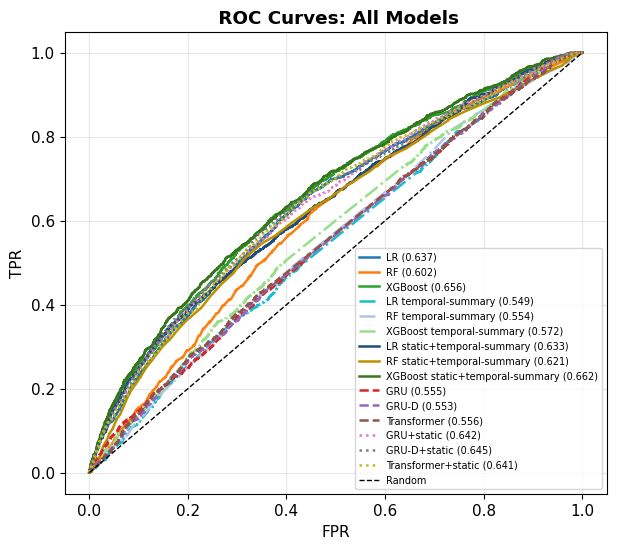

In [ ]:
# ROC Curves
plt.figure(figsize=(7,6))
for name, p_raw, _, _ in MODEL_PROBS:
    auc = roc_auc_score(y_test, p_raw)
    fpr, tpr, _ = roc_curve(y_test, p_raw)
    plt.plot(fpr, tpr, label=f'{name} ({auc:.3f})', color=COLORS[name], linestyle=LS[name], linewidth=1.8)
plt.plot([0,1],[0,1],'k--',linewidth=1,label='Random')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title(' ROC Curves: All Models', fontweight='bold')
plt.legend(fontsize=7, loc='lower right'); plt.grid(alpha=0.3)
save_fig('rq1_fig1_roc_curves'); plt.show()

Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq1_fig2_pr_curves.pdf


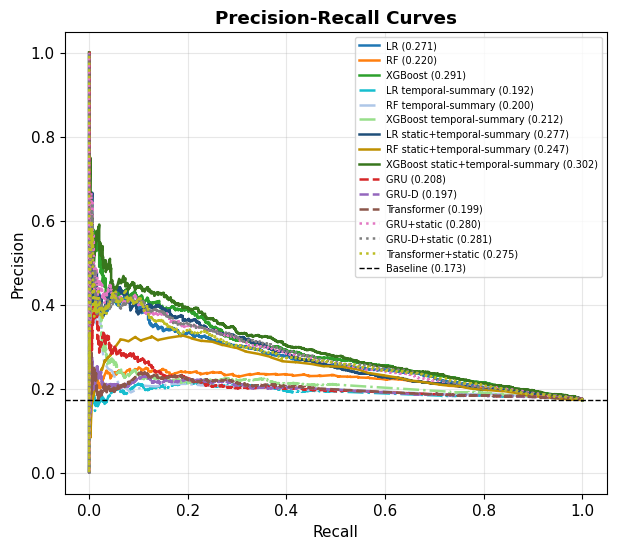

In [ ]:
# PR Curves
plt.figure(figsize=(7,6))
for name, p_raw, _, _ in MODEL_PROBS:
    ap = average_precision_score(y_test, p_raw)
    prec, rec, _ = precision_recall_curve(y_test, p_raw)
    plt.plot(rec, prec, label=f'{name} ({ap:.3f})', color=COLORS[name], linestyle=LS[name], linewidth=1.8)
plt.axhline(y=y_test.mean(), color='k', linestyle='--', linewidth=1, label=f'Baseline ({y_test.mean():.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curves', fontweight='bold')
plt.legend(fontsize=7); plt.grid(alpha=0.3)
save_fig('rq1_fig2_pr_curves'); plt.show()

Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq1_fig3_ablation_auroc.pdf


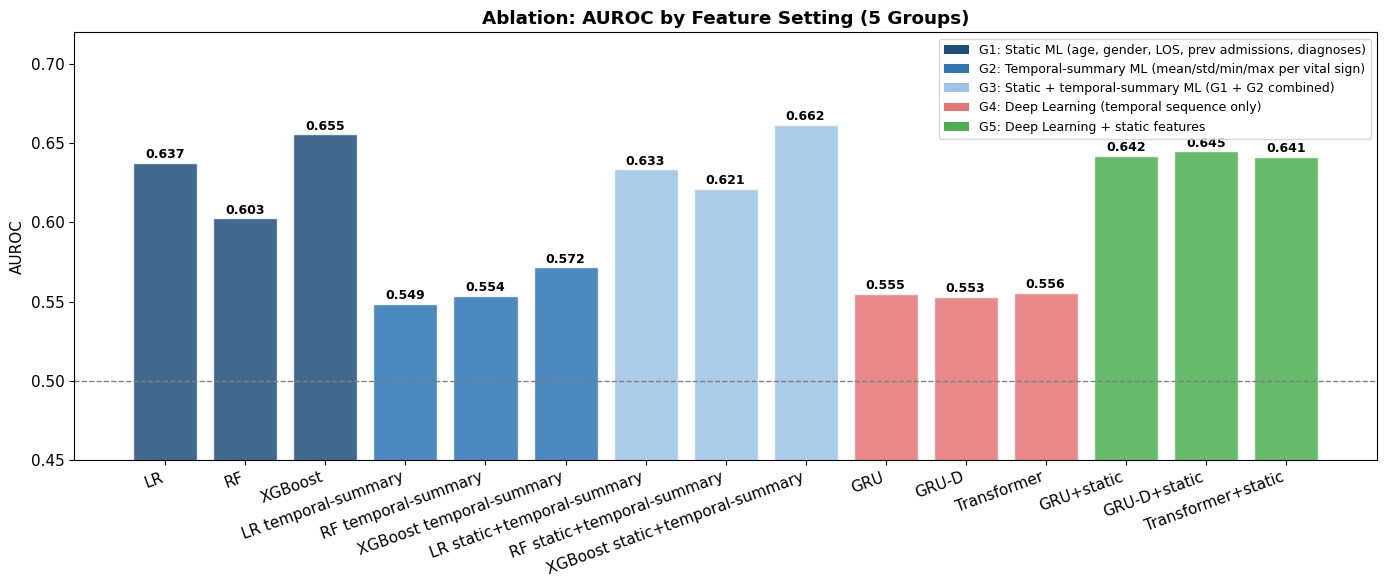

In [ ]:
# ── RQ1 Figure 3: Ablation — AUROC by Feature Setting (5 groups) ──
from matplotlib.patches import Patch

type_colors_5 = {
    'Static ML':                     '#1f4e79',
    'Temporal-summary ML':           '#2E75B6',
    'Static+temporal-summary ML':    '#9DC3E6',
    'Deep Learning':                 '#E57373',
    'DL+Static':                     '#4CAF50'
}

all_names  = [r[0] for r in MODEL_PROBS]
all_aurocs = df_metrics.set_index('Model').loc[all_names, 'AUROC'].values
all_types  = df_metrics.set_index('Model').loc[all_names, 'Type'].values
bar_colors = [type_colors_5[t] for t in all_types]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(all_names, all_aurocs, color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, all_aurocs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

legend_elements = [
    Patch(facecolor='#1f4e79', label='G1: Static ML (age, gender, LOS, prev admissions, diagnoses)'),
    Patch(facecolor='#2E75B6', label='G2: Temporal-summary ML (mean/std/min/max per vital sign)'),
    Patch(facecolor='#9DC3E6', label='G3: Static + temporal-summary ML (G1 + G2 combined)'),
    Patch(facecolor='#E57373', label='G4: Deep Learning (temporal sequence only)'),
    Patch(facecolor='#4CAF50', label='G5: Deep Learning + static features'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('AUROC'); ax.set_ylim(0.45, 0.72)
ax.set_title('Ablation: AUROC by Feature Setting (5 Groups)', fontweight='bold')
plt.xticks(rotation=20, ha='right'); plt.tight_layout()
save_fig('rq1_fig3_ablation_auroc')
plt.show()

Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq1_fig4_xgboost_variants.pdf


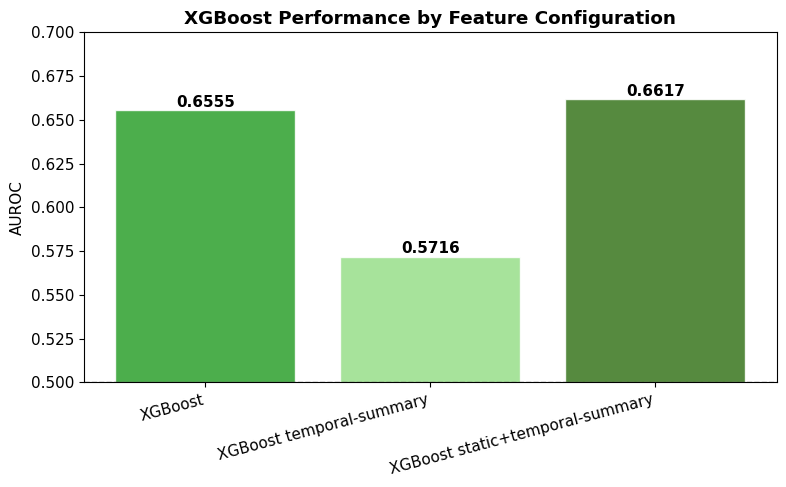

In [ ]:
# ── RQ1 Figure 4: XGBoost variants — effect of adding temporal summaries ──
xgb_variants = ['XGBoost', 'XGBoost temporal-summary', 'XGBoost static+temporal-summary']
xgb_aurocs   = df_metrics.set_index('Model').loc[xgb_variants, 'AUROC'].values
xgb_colors   = [COLORS[n] for n in xgb_variants]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(xgb_variants, xgb_aurocs, color=xgb_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, xgb_aurocs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('AUROC'); ax.set_ylim(0.50, 0.70)
ax.set_title('XGBoost Performance by Feature Configuration', fontweight='bold')
plt.xticks(rotation=15, ha='right'); plt.tight_layout()
save_fig('rq1_fig4_xgboost_variants')
plt.show()

Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq1_fig4_xgboost_variants.pdf


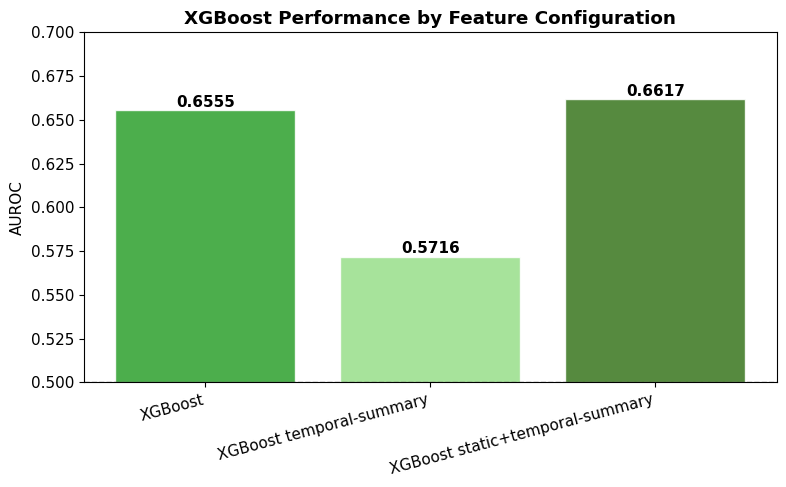

In [ ]:
# ── RQ1 Figure 4: XGBoost variants — effect of adding temporal summaries ──
xgb_variants = ['XGBoost', 'XGBoost temporal-summary', 'XGBoost static+temporal-summary']
xgb_aurocs   = df_metrics.set_index('Model').loc[xgb_variants, 'AUROC'].values
xgb_colors   = [COLORS[n] for n in xgb_variants]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(xgb_variants, xgb_aurocs, color=xgb_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, xgb_aurocs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('AUROC'); ax.set_ylim(0.50, 0.70)
ax.set_title('XGBoost Performance by Feature Configuration', fontweight='bold')
plt.xticks(rotation=15, ha='right'); plt.tight_layout()
save_fig('rq1_fig4_xgboost_variants')
plt.show()

In [ ]:
# Original static-XGBoost subgroup analysis has been superseded by the RQ4
# best-deployable-model subgroup robustness analysis below. This avoids reporting
# duplicate or inconsistent subgroup tables.
print('Subgroup robustness is reported in RQ4 using BEST_MODEL_NAME =', BEST_MODEL_NAME)


Subgroup robustness is reported in RQ4 using BEST_MODEL_NAME = XGBoost static+temporal-summary


RQ2

Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq2_fig1_model_complexity_comparison.pdf


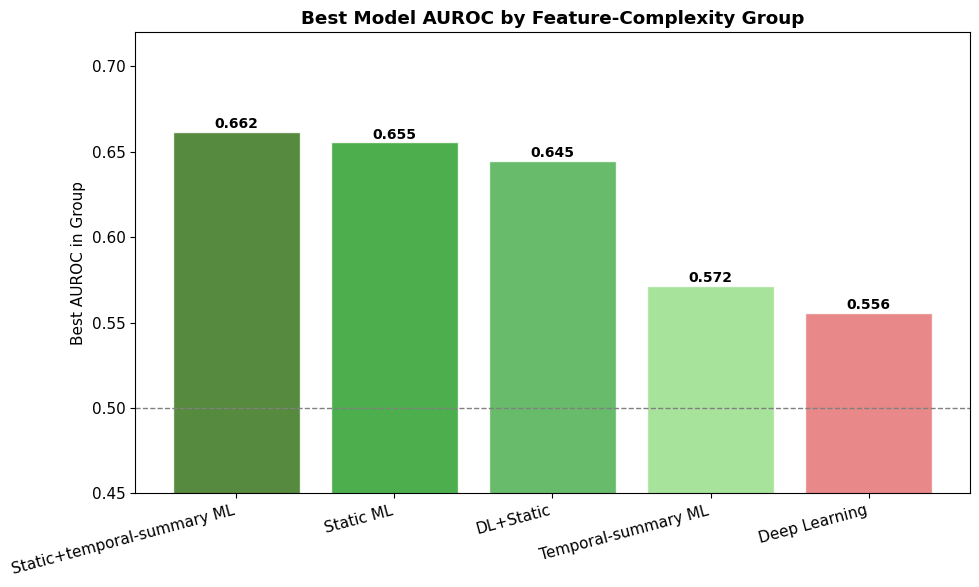

In [ ]:
# ── RQ2 Figure 1: Added Value of Model Complexity ──
df_complexity = pd.read_csv(TABLE_STR + '/rq2_added_value_model_complexity.csv')
df_complexity = df_complexity.sort_values('Best_AUROC', ascending=False)

group_colors = {
    'Static+temporal-summary ML': '#38761d',
    'Static ML':                   '#2ca02c',
    'DL+Static':                   '#4CAF50',
    'Temporal-summary ML':         '#98df8a',
    'Deep Learning':               '#E57373',
}

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    df_complexity.Model_Group,
    df_complexity.Best_AUROC,
    color=[group_colors.get(g, '#999999') for g in df_complexity.Model_Group],
    alpha=0.85, edgecolor='white'
)
for bar, val in zip(bars, df_complexity.Best_AUROC):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Best AUROC in Group')
ax.set_ylim(0.45, 0.72)
ax.set_title('Best Model AUROC by Feature-Complexity Group', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
save_fig('rq2_fig1_model_complexity_comparison')
plt.show()

---
# RQ3 — Calibration and Reliability for Clinical Prioritization

In [ ]:
save_table(
    df_metrics[['Model','Type','Brier','Brier_CI','ECE','Cal_Slope','Cal_Intercept']],
    'rq3_calibration_metrics_raw'
)
save_table(df_calibration_raw_vs_calibrated, 'rq3_calibration_raw_vs_platt')
print(df_metrics[['Model','Type','Brier','Brier_CI','ECE','Cal_Slope','Cal_Intercept']].to_string(index=False))
print('\nRaw vs Platt-calibrated probabilities:')
print(df_calibration_raw_vs_calibrated[['Model','Raw_Brier','Calibrated_Brier','Raw_ECE','Calibrated_ECE','Brier_Improved_After_Calibration','ECE_Improved_After_Calibration']].to_string(index=False))


Saved table: /content/drive/MyDrive/Thesis/thesis_v3/tables/rq3_calibration_metrics_raw.csv
Saved table: /content/drive/MyDrive/Thesis/thesis_v3/tables/rq3_calibration_raw_vs_platt.csv
                          Model                       Type  Brier         Brier_CI    ECE  Cal_Slope  Cal_Intercept
                             LR                  Static ML 0.1390  [0.1332, 0.144] 0.0164     0.8152        -0.3409
                             RF                  Static ML 0.1592 [0.1528, 0.1644] 0.0987     0.0969        -1.3227
                        XGBoost                  Static ML 0.1362 [0.1306, 0.1411] 0.0129     0.9073        -0.2027
            LR temporal-summary        Temporal-summary ML 0.1425 [0.1367, 0.1477] 0.0096     0.6710        -0.5521
            RF temporal-summary        Temporal-summary ML 0.1445 [0.1393, 0.1494] 0.0320     0.4145        -0.9737
       XGBoost temporal-summary        Temporal-summary ML 0.1416  [0.136, 0.1467] 0.0121     0.7853        -0.3825
   

In [ ]:
# ── Define decision_curve function ──
def decision_curve(y_true, probs, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.50, 100)
    n = len(y_true); nb = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        tp = ((preds==1) & (y_true==1)).sum()
        fp = ((preds==1) & (y_true==0)).sum()
        nb.append(tp/n - fp/n*(t/(1-t)))
    return np.array(nb)

# ── RQ3 Figures — 6 representative models (2x3 grid) ──
RQ3_MODELS = [
    'XGBoost',
    'XGBoost static+temporal-summary',
    'GRU-D',
    'LR',
    'GRU-D+static',
    'Transformer+static'
]

Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq3_fig1_reliability_diagrams.pdf


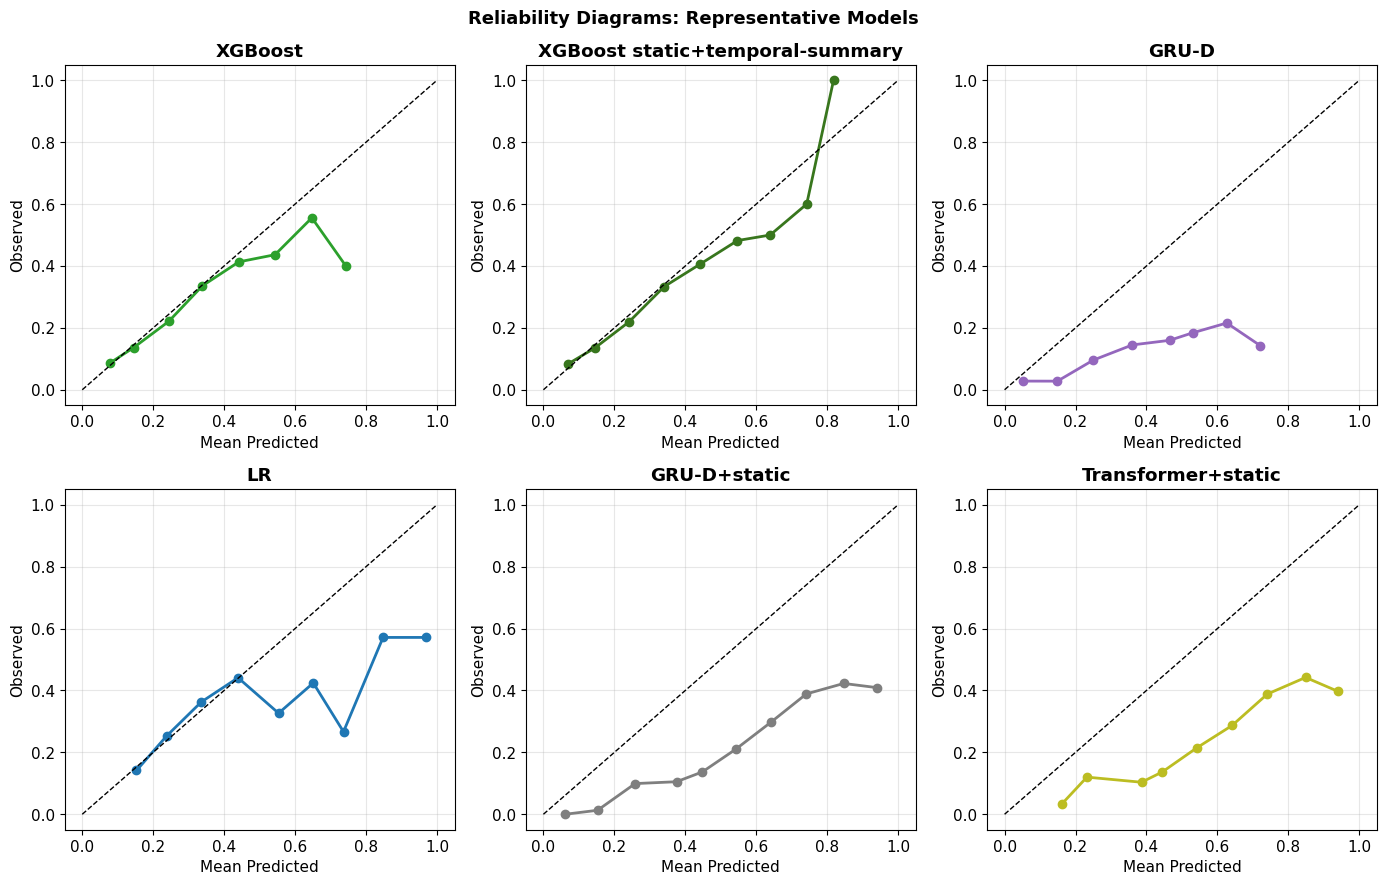

Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq3_fig2_dca.pdf


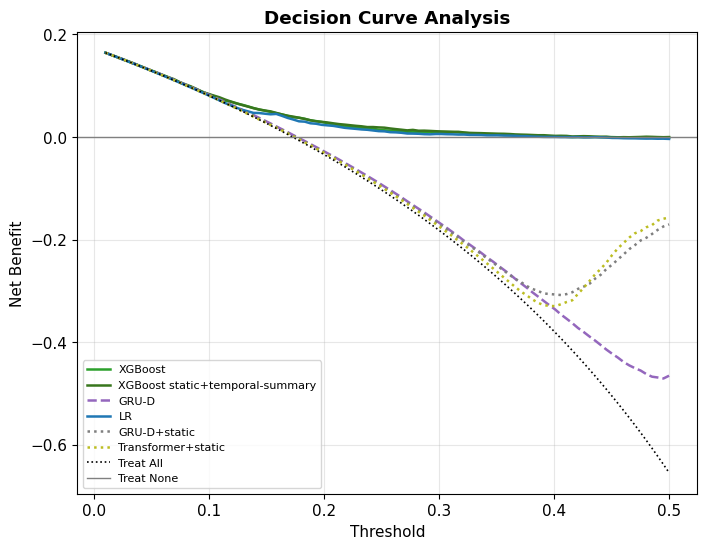

Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq3_fig3_obs_vs_pred.pdf


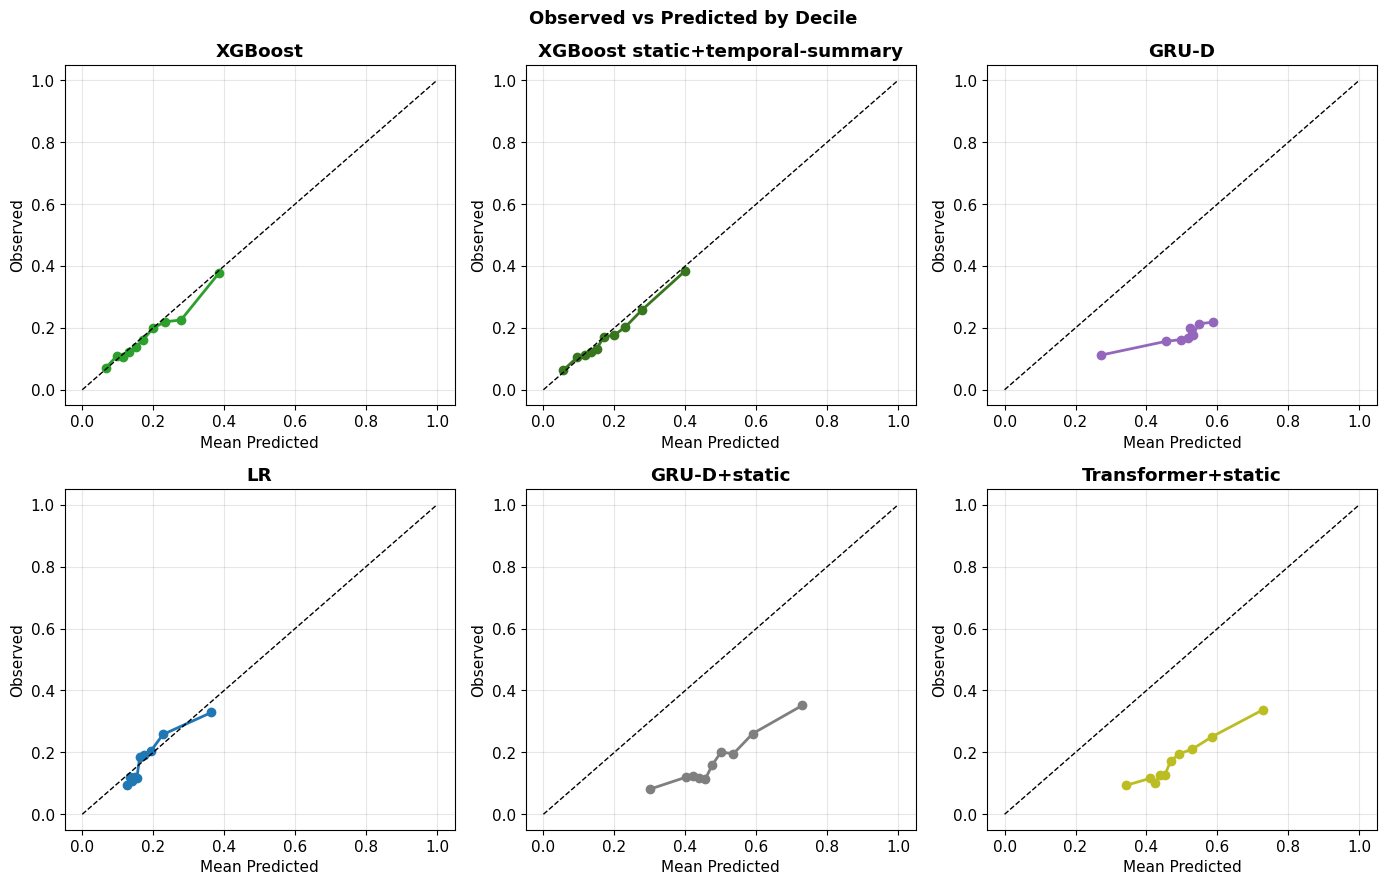

RQ3 figures regenerated with 6 representative models.


In [ ]:
# ── RQ3 Figures — 6 representative models (2x3 grid) ──
RQ3_MODELS = [
    'XGBoost',
    'XGBoost static+temporal-summary',
    'GRU-D',
    'LR',
    'GRU-D+static',
    'Transformer+static'
]

model_lookup_raw = {name: p_raw for name, p_raw, _, _ in MODEL_PROBS}

# RQ3 Figure 1: Reliability diagrams
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, name in zip(axes.flatten(), RQ3_MODELS):
    p_raw = model_lookup_raw[name]
    fp, mp = calibration_curve(y_test, p_raw, n_bins=10)
    ax.plot(mp, fp, 'o-', color=COLORS[name], linewidth=2)
    ax.plot([0,1],[0,1],'k--', linewidth=1)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Mean Predicted'); ax.set_ylabel('Observed'); ax.grid(alpha=0.3)
fig.suptitle('Reliability Diagrams: Representative Models', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('rq3_fig1_reliability_diagrams')
plt.show()

# RQ3 Figure 2: Decision Curve Analysis
thresholds = np.linspace(0.01, 0.50, 100)
plt.figure(figsize=(8, 6))
for name in RQ3_MODELS:
    p_raw = model_lookup_raw[name]
    plt.plot(thresholds, decision_curve(y_test, p_raw, thresholds),
             label=name, color=COLORS[name], linestyle=LS[name], linewidth=1.8)
nb_all = [y_test.mean() - (1-y_test.mean())*(t/(1-t)) for t in thresholds]
plt.plot(thresholds, nb_all, 'k:', linewidth=1.2, label='Treat All')
plt.axhline(0, color='gray', linewidth=1, label='Treat None')
plt.xlabel('Threshold'); plt.ylabel('Net Benefit')
plt.title('Decision Curve Analysis', fontweight='bold')
plt.legend(fontsize=8); plt.grid(alpha=0.3)
save_fig('rq3_fig2_dca')
plt.show()

# RQ3 Figure 3: Observed vs Predicted by Decile
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, name in zip(axes.flatten(), RQ3_MODELS):
    p_raw = model_lookup_raw[name]
    deciles = pd.qcut(p_raw, q=10, labels=False, duplicates='drop')
    obs, pred = [], []
    for d in sorted(np.unique(deciles)):
        mask = deciles == d
        obs.append(y_test[mask].mean()); pred.append(p_raw[mask].mean())
    ax.plot(pred, obs, 'o-', color=COLORS[name], linewidth=2)
    ax.plot([0,1],[0,1],'k--', linewidth=1)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Mean Predicted'); ax.set_ylabel('Observed'); ax.grid(alpha=0.3)
fig.suptitle('Observed vs Predicted by Decile', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('rq3_fig3_obs_vs_pred')
plt.show()

print('RQ3 figures regenerated with 6 representative models.')

Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq3_calibration_before_after_xgboost.pdf


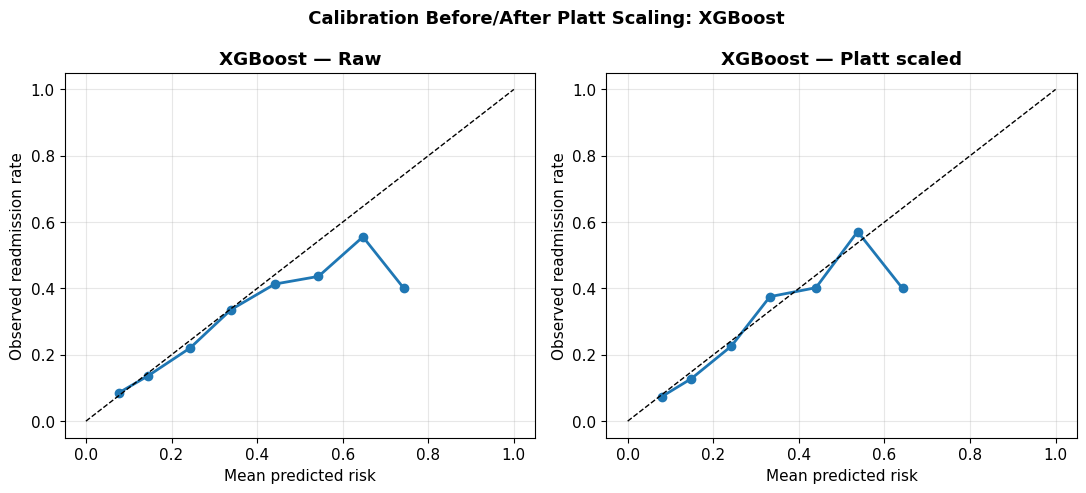

Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq3_calibration_before_after_xgboost_staticplustemporal-summary.pdf


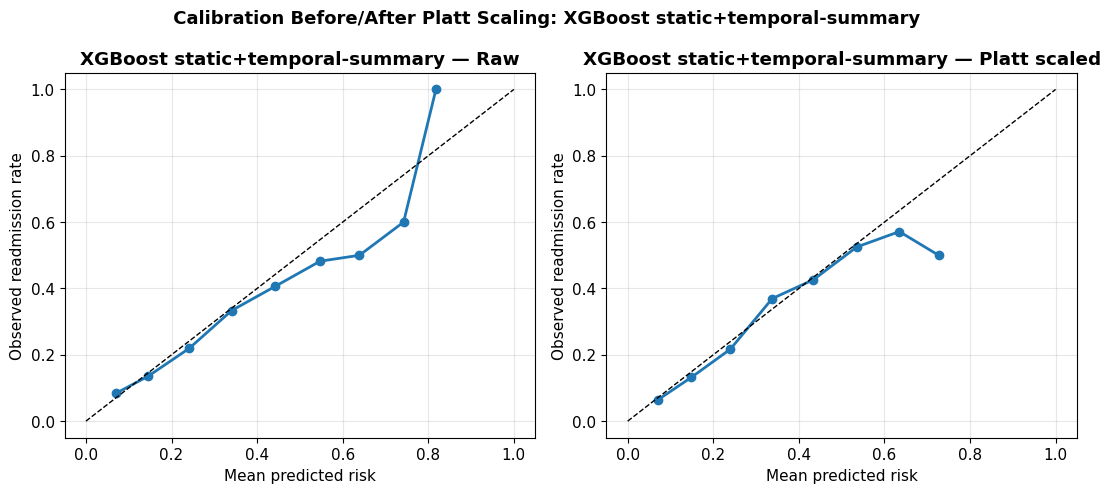

In [ ]:
# Calibration before/after Platt scaling for the best-ranked model and original static XGBoost.
model_lookup = {name: (p_raw, p_cal) for name, p_raw, p_cal, _ in MODEL_PROBS}
models_to_plot = []
if 'XGBoost' in model_lookup:
    models_to_plot.append('XGBoost')
if BEST_MODEL_NAME not in models_to_plot:
    models_to_plot.append(BEST_MODEL_NAME)

for model_name in models_to_plot:
    p_raw, p_cal = model_lookup[model_name]
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, p, title in [(axes[0], p_raw, f'{model_name} — Raw'), (axes[1], p_cal, f'{model_name} — Platt scaled')]:
        fp, mp = calibration_curve(y_test, p, n_bins=10)
        ax.plot(mp, fp, 'o-', linewidth=2)
        ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Mean predicted risk')
        ax.set_ylabel('Observed readmission rate')
        ax.grid(alpha=0.3)
    fig.suptitle(f' Calibration Before/After Platt Scaling: {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_fig('rq3_calibration_before_after_' + model_name.lower().replace(' ', '_').replace('+','plus'))
    plt.show()


In [ ]:
import os
to_delete = [
    FIG_STR + '/rq2_fig3_dca.pdf',
    FIG_STR + '/rq2_fig4_obs_vs_pred.pdf'
]
for f in to_delete:
    if os.path.exists(f):
        os.remove(f)
        print(f'Deleted: {f}')

---
# RQ4 — Robustness Under Temporal and Data-Quality Variation

                          Model  Year  AUROC         AUROC_CI  AUPRC         AUPRC_CI    N  Events  Readmission_Rate          Temporal_Claim_Allowed
                             LR  2162 0.6344 [0.5847, 0.6764] 0.3186  [0.254, 0.3824] 1053     199            0.1890 strict chronological validation
                             LR  2163 0.6389 [0.5916, 0.6853] 0.2556   [0.205, 0.324] 1057     162            0.1533 strict chronological validation
                             LR  2164 0.6464 [0.6008, 0.6909] 0.2565 [0.2112, 0.3148] 1085     180            0.1659 strict chronological validation
                             LR  2165 0.6452  [0.5954, 0.693] 0.2476 [0.2076, 0.3012] 1034     175            0.1692 strict chronological validation
                             LR  2166 0.6560 [0.6087, 0.7018] 0.2587 [0.2115, 0.3151] 1027     170            0.1655 strict chronological validation
                             LR  2167 0.6524 [0.6077, 0.6889] 0.3498 [0.2893, 0.4162] 1109     202        

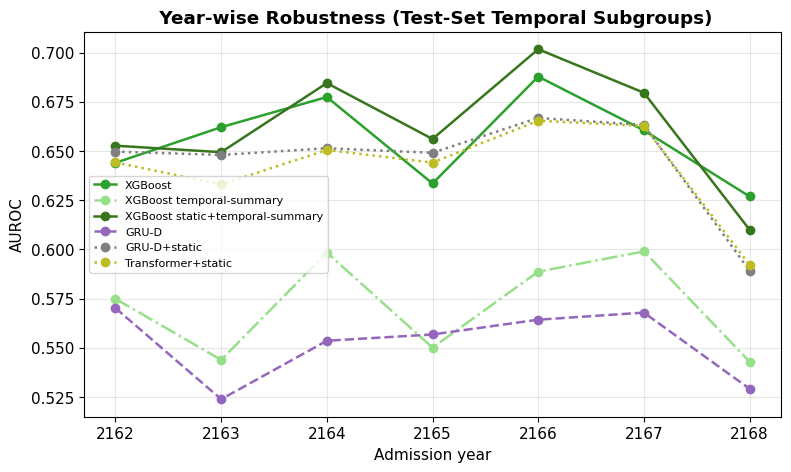

          Subgroup  Group  AUROC         AUROC_CI    N  Events  Readmission_Rate                           Model
               Age    Low 0.6906 [0.6645, 0.7177] 2546     488            0.1917 XGBoost static+temporal-summary
               Age    Mid 0.6598 [0.6309, 0.6896] 2504     398            0.1589 XGBoost static+temporal-summary
               Age   High 0.6252 [0.5959, 0.6552] 2366     395            0.1669 XGBoost static+temporal-summary
               LOS  Short 0.6696 [0.6417, 0.6976] 3032     421            0.1389 XGBoost static+temporal-summary
               LOS Medium 0.6464 [0.6127, 0.6801] 1933     340            0.1759 XGBoost static+temporal-summary
               LOS   Long 0.6335 [0.6085, 0.6574] 2451     520            0.2122 XGBoost static+temporal-summary
Comorbidity burden    Low 0.6400 [0.6089, 0.6747] 2579     353            0.1369 XGBoost static+temporal-summary
Comorbidity burden Medium 0.6421 [0.6124, 0.6682] 2496     451            0.1807 XGBoost static+

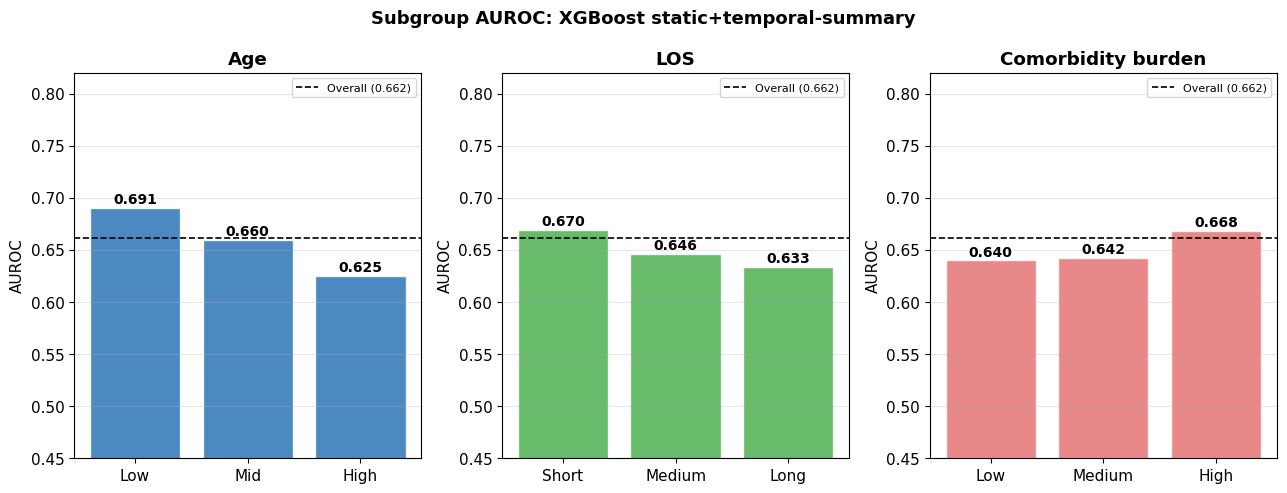

In [ ]:
unique_years = sorted(np.unique(years_test))
rq4_year_rows = []
for name, p_raw, _, _ in MODEL_PROBS:
    for yr in unique_years:
        mask = years_test == yr
        if mask.sum() < 20 or y_test[mask].sum() < 5 or (mask.sum() - y_test[mask].sum()) < 5:
            continue
        try:
            auroc, auroc_ci = bootstrap_metric_summary(y_test[mask], p_raw[mask], roc_auc_score, n_boot=300, seed=SEED)
            auprc, auprc_ci = bootstrap_metric_summary(y_test[mask], p_raw[mask], average_precision_score, n_boot=300, seed=SEED)
            rq4_year_rows.append({
                'Model': name,
                'Year': int(yr),
                'AUROC': auroc,
                'AUROC_CI': auroc_ci,
                'AUPRC': auprc,
                'AUPRC_CI': auprc_ci,
                'N': int(mask.sum()),
                'Events': int(y_test[mask].sum()),
                'Readmission_Rate': round(float(y_test[mask].mean()), 4),
                'Temporal_Claim_Allowed': TEMPORAL_VALIDATION_CLAIM
            })
        except Exception:
            pass

df_rq4_year = pd.DataFrame(rq4_year_rows)
print(df_rq4_year.to_string(index=False))
save_table(df_rq4_year, 'rq4_yearwise_temporal_robustness')

# Plot only the most relevant models to avoid an unreadable figure.
plot_models = [m for m in ['XGBoost', 'XGBoost temporal-summary', 'XGBoost static+temporal-summary','GRU-D', 'GRU-D+static', 'Transformer+static'] if m in df_rq4_year.Model.unique()]
plt.figure(figsize=(9,5))
for name in plot_models:
    d = df_rq4_year[df_rq4_year.Model == name]
    plt.plot(d.Year, d.AUROC, 'o-', label=name, color=COLORS[name], linestyle=LS[name], linewidth=1.8)
plt.xlabel('Admission year')
plt.ylabel('AUROC')
plt.title(' Year-wise Robustness (Test-Set Temporal Subgroups)', fontweight='bold')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
save_fig('rq4_fig1_yearwise_auroc'); plt.show()

# Subgroup robustness for the selected best deployable model.
X_test_static = np.load(ARRAY_STR + '/X_static_test.npy')
feat_df = pd.DataFrame(X_test_static, columns=STATIC_FEATURES)

def auroc_by_group(groups, name, probs):
    rows = []
    for label in groups.cat.categories:
        mask = (groups == label).values
        if mask.sum() > 20 and y_test[mask].sum() >= 5 and (mask.sum() - y_test[mask].sum()) >= 5:
            auroc, auroc_ci = bootstrap_metric_summary(y_test[mask], probs[mask], roc_auc_score, n_boot=300, seed=SEED)
            rows.append({
                'Subgroup': name,
                'Group': str(label),
                'AUROC': auroc,
                'AUROC_CI': auroc_ci,
                'N': int(mask.sum()),
                'Events': int(y_test[mask].sum()),
                'Readmission_Rate': round(float(y_test[mask].mean()), 4),
                'Model': BEST_MODEL_NAME
            })
    return rows

def safe_tertile_groups(series, base_labels):
    raw = pd.qcut(series, q=3, duplicates='drop')
    n = len(raw.cat.categories)
    labels = base_labels[:n]
    mapping = {cat: labels[i] for i, cat in enumerate(raw.cat.categories)}
    return raw.map(mapping).astype(pd.CategoricalDtype(categories=labels, ordered=True))

age_grp  = safe_tertile_groups(feat_df['age'], ['Low','Mid','High'])
los_grp  = safe_tertile_groups(feat_df['los_days_capped'], ['Short','Medium','Long'])
diag_grp = safe_tertile_groups(feat_df['num_diagnoses'], ['Low','Medium','High'])

df_sub = pd.DataFrame(
    auroc_by_group(age_grp, 'Age', BEST_MODEL_PROBS) +
    auroc_by_group(los_grp, 'LOS', BEST_MODEL_PROBS) +
    auroc_by_group(diag_grp, 'Comorbidity burden', BEST_MODEL_PROBS)
)
print(df_sub.to_string(index=False))
save_table(df_sub, 'rq4_subgroup_robustness_best_model')

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
overall = roc_auc_score(y_test, BEST_MODEL_PROBS)
sgc = {'Age':'#2E75B6','LOS':'#4CAF50','Comorbidity burden':'#E57373'}
for ax, sg in zip(axes, ['Age','LOS','Comorbidity burden']):
    d = df_sub[df_sub.Subgroup == sg]
    bars = ax.bar(d.Group, d.AUROC, color=sgc[sg], alpha=0.85, edgecolor='white')
    ax.axhline(y=overall, color='black', linestyle='--', linewidth=1.2, label=f'Overall ({overall:.3f})')
    for bar, val in zip(bars, d.AUROC):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004, f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_ylim(0.45, 0.82)
    ax.set_title(sg, fontweight='bold')
    ax.set_ylabel('AUROC')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')
fig.suptitle(f'Subgroup AUROC: {BEST_MODEL_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout(); save_fig('rq4_fig2_subgroup_best_model'); plt.show()


---
# RQ4b — Missingness Stress Testing of Temporal Models

      Model  Extra_Missing_Pct  AUROC_Mean  AUROC_SD  AUPRC_Mean  AUPRC_SD  Brier_Mean  Brier_SD  ECE_Mean  ECE_SD  Runs
        GRU                0.0      0.5550       NaN      0.2084       NaN      0.2541       NaN    0.3320     NaN     1
        GRU                0.1      0.5555    0.0025      0.2078    0.0008      0.2537    0.0002    0.3318  0.0003     5
        GRU                0.2      0.5550    0.0024      0.2062    0.0014      0.2534    0.0002    0.3319  0.0003     5
        GRU                0.3      0.5536    0.0017      0.2056    0.0025      0.2533    0.0003    0.3320  0.0004     5
      GRU-D                0.0      0.5531       NaN      0.1970       NaN      0.2506       NaN    0.3238     NaN     1
      GRU-D                0.1      0.5505    0.0013      0.1968    0.0007      0.2500    0.0000    0.3229  0.0001     5
      GRU-D                0.2      0.5487    0.0012      0.1959    0.0017      0.2495    0.0002    0.3224  0.0002     5
      GRU-D                0.3  

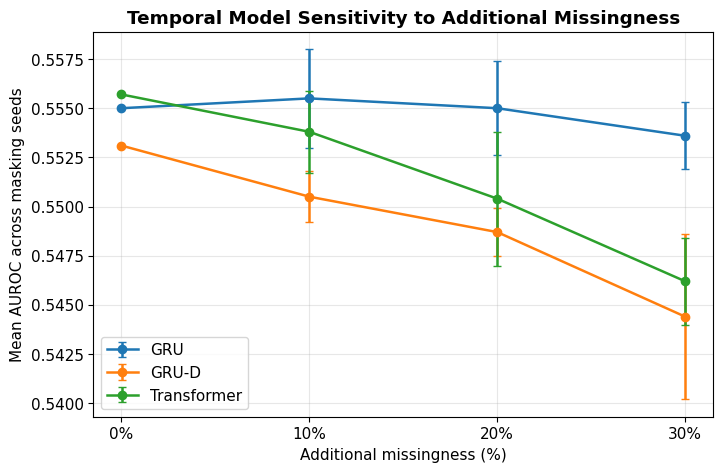

In [ ]:
def mask_additional(X, M, pct_extra, seed=SEED):
    rng = np.random.default_rng(seed)
    X_m = X.clone()
    M_m = M.clone()
    observed_pos = (M_m == 1).nonzero(as_tuple=True)
    n_obs = len(observed_pos[0])
    n_mask = int(n_obs * pct_extra)
    if n_mask > 0:
        idx = rng.choice(n_obs, n_mask, replace=False)
        for k in idx:
            i, t, f = observed_pos[0][k], observed_pos[1][k], observed_pos[2][k]
            X_m[i, t, f] = 0.0
            M_m[i, t, f] = 0.0
    D_m = torch.tensor(compute_delta(M_m.numpy()), dtype=torch.float32)
    return X_m, M_m, D_m

DL_EVAL = [('GRU', gru_m), ('GRU-D', grud_m), ('Transformer', trans_m)]
miss_levels = [0.0, 0.10, 0.20, 0.30]
stress_seeds = [11, 22, 33, 44, 55]
rq4_miss_rows = []

for name, model in DL_EVAL:
    model.eval()
    for pct in miss_levels:
        seed_list = [SEED] if pct == 0.0 else stress_seeds
        for s in seed_list:
            if pct == 0.0:
                X_m, M_m, D_m = Xt_test, Mt_test, Dt_test
            else:
                X_m, M_m, D_m = mask_additional(Xt_test, Mt_test, pct, seed=s)
            loader_m = DataLoader(TensorDataset(X_m, M_m, D_m, yt_test), batch_size=BATCH_SIZE)
            p_m = get_probs(model, loader_m)
            rq4_miss_rows.append({
                'Model': name,
                'Extra_Missing_Pct': pct,
                'Seed': int(s),
                'AUROC': round(float(roc_auc_score(y_test, p_m)), 4),
                'AUPRC': round(float(average_precision_score(y_test, p_m)), 4),
                'Brier': round(float(brier_score_loss(y_test, p_m)), 4),
                'ECE': compute_ece(y_test, p_m)
            })

df_rq4_missing_runs = pd.DataFrame(rq4_miss_rows)
df_rq4_missing_summary = (
    df_rq4_missing_runs
    .groupby(['Model','Extra_Missing_Pct'])
    .agg(
        AUROC_Mean=('AUROC','mean'), AUROC_SD=('AUROC','std'),
        AUPRC_Mean=('AUPRC','mean'), AUPRC_SD=('AUPRC','std'),
        Brier_Mean=('Brier','mean'), Brier_SD=('Brier','std'),
        ECE_Mean=('ECE','mean'), ECE_SD=('ECE','std'),
        Runs=('Seed','count')
    )
    .reset_index()
)
for col in ['AUROC_Mean','AUROC_SD','AUPRC_Mean','AUPRC_SD','Brier_Mean','Brier_SD','ECE_Mean','ECE_SD']:
    df_rq4_missing_summary[col] = df_rq4_missing_summary[col].round(4)

print(df_rq4_missing_summary.to_string(index=False))
save_table(df_rq4_missing_runs, 'rq4_missingness_stress_test_all_runs')
save_table(df_rq4_missing_summary, 'rq4_missingness_stress_test_summary')

plt.figure(figsize=(8,5))
for name in ['GRU','GRU-D','Transformer']:
    d = df_rq4_missing_summary[df_rq4_missing_summary.Model == name]
    x = [f'{int(p*100)}%' for p in d.Extra_Missing_Pct]
    y = d.AUROC_Mean.values
    yerr = d.AUROC_SD.fillna(0).values
    plt.errorbar(x, y, yerr=yerr, marker='o', label=name, linewidth=1.8, capsize=3)
plt.xlabel('Additional missingness (%)')
plt.ylabel('Mean AUROC across masking seeds')
plt.title('Temporal Model Sensitivity to Additional Missingness', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
save_fig('rq4b_fig1_auroc_vs_missingness_repeated'); plt.show()


---
# RQ5 — Resource-Constrained Risk Stratification

Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq5_fig1_capture_curve.pdf


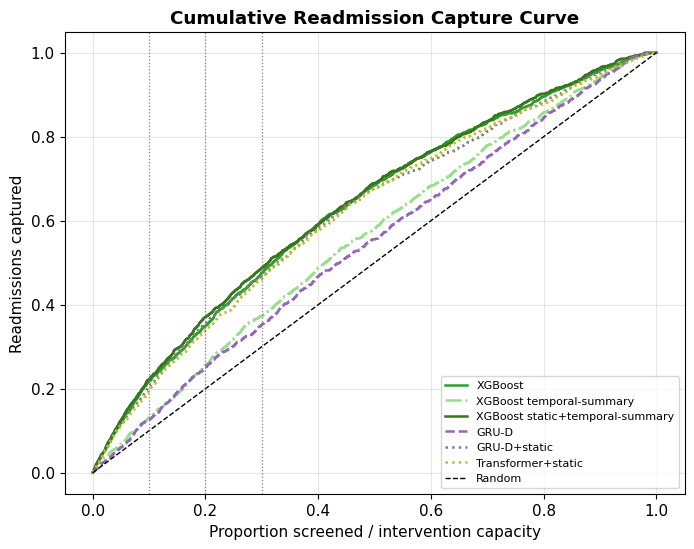

In [ ]:
# ── RQ5 Figure 1: Capture Curve — 6 representative models ──
RQ5_MODELS = [
    'XGBoost',
    'XGBoost temporal-summary',
    'XGBoost static+temporal-summary',
    'GRU-D',
    'GRU-D+static',
    'Transformer+static'
]

plt.figure(figsize=(8, 6))
for name in RQ5_MODELS:
    p_raw = model_lookup_raw[name]
    sorted_idx = np.argsort(p_raw)[::-1]
    cum = np.cumsum(y_test[sorted_idx]) / y_test.sum()
    pct = np.arange(1, len(y_test)+1) / len(y_test)
    plt.plot(pct, cum, label=name, color=COLORS[name], linestyle=LS[name], linewidth=1.8)
plt.plot([0,1],[0,1],'k--',linewidth=1,label='Random')
for cap in [0.10, 0.20, 0.30]:
    plt.axvline(cap, color='gray', linestyle=':', linewidth=0.9)
plt.xlabel('Proportion screened / intervention capacity')
plt.ylabel('Readmissions captured')
plt.title('Cumulative Readmission Capture Curve', fontweight='bold')
plt.legend(fontsize=8); plt.grid(alpha=0.3)
save_fig('rq5_fig1_capture_curve')
plt.show()

Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq5_fig2_tier_distribution.pdf


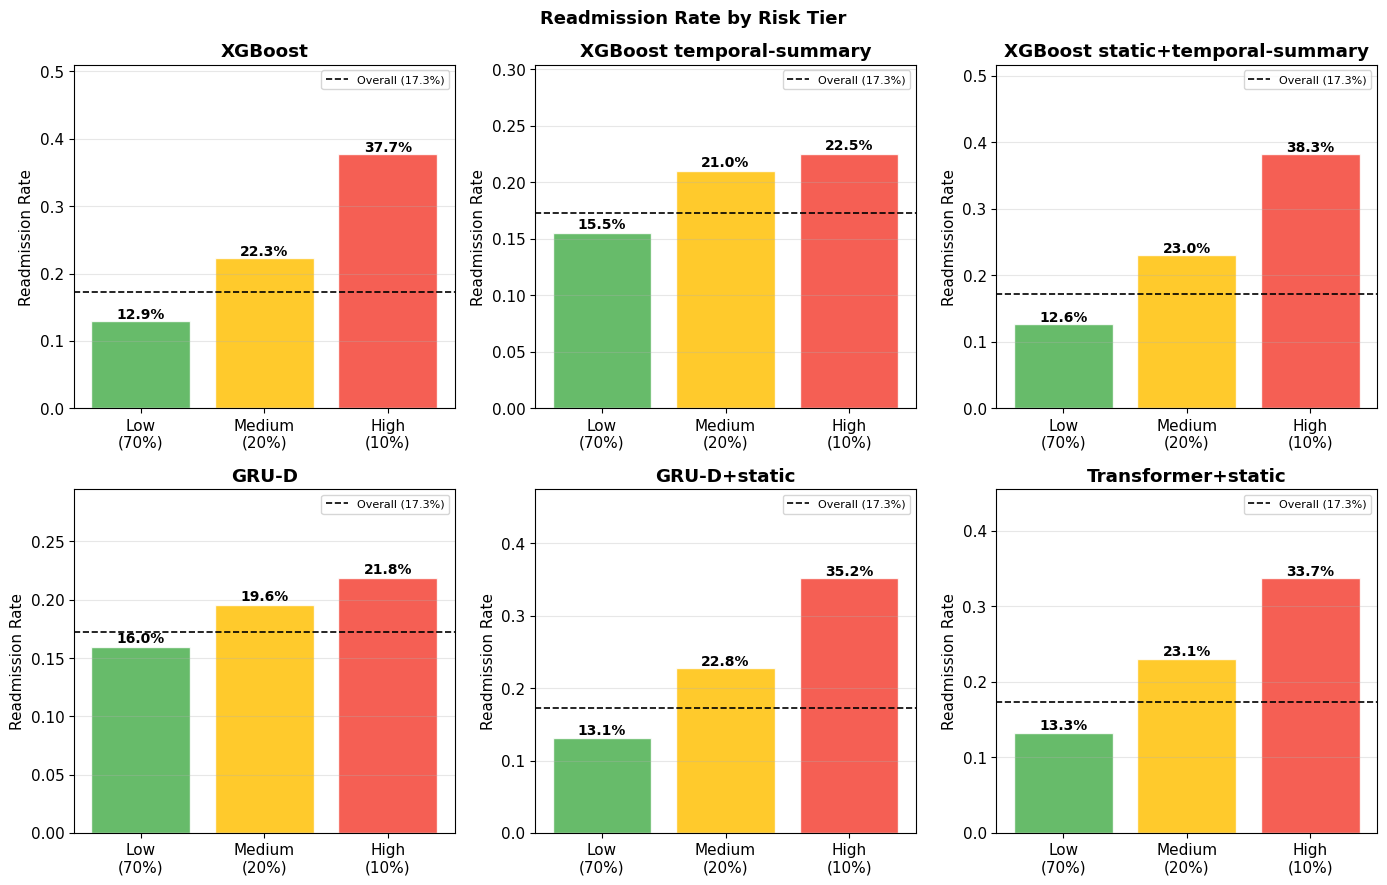

In [ ]:
# ── RQ5 Figure 2: Risk Tier Distribution — 6 representative models ──
RQ5_MODELS = [
    'XGBoost',
    'XGBoost temporal-summary',
    'XGBoost static+temporal-summary',
    'GRU-D',
    'GRU-D+static',
    'Transformer+static'
]

model_lookup_raw = {name: p_raw for name, p_raw, _, _ in MODEL_PROBS}
tier_colors = ['#4CAF50', '#FFC107', '#F44336']

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, name in zip(axes.flatten(), RQ5_MODELS):
    p_raw = model_lookup_raw[name]
    p90 = np.percentile(p_raw, 90); p70 = np.percentile(p_raw, 70)
    high   = y_test[p_raw >= p90]
    medium = y_test[(p_raw >= p70) & (p_raw < p90)]
    low    = y_test[p_raw < p70]
    rates  = [low.mean(), medium.mean(), high.mean()]
    labels = ['Low\n(70%)', 'Medium\n(20%)', 'High\n(10%)']
    bars   = ax.bar(labels, rates, color=tier_colors, alpha=0.85, edgecolor='white')
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{rate:.1%}', ha='center', fontweight='bold', fontsize=10)
    ax.axhline(y=y_test.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Overall ({y_test.mean():.1%})')
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Readmission Rate')
    ax.set_ylim(0, max(rates)*1.35)
    ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

fig.suptitle('Readmission Rate by Risk Tier', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('rq5_fig2_tier_distribution')
plt.show()

Saved table: /content/drive/MyDrive/Thesis/thesis_v3/tables/rq5_enrichment_ratio.csv
Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq5_fig3_enrichment_ratio.pdf


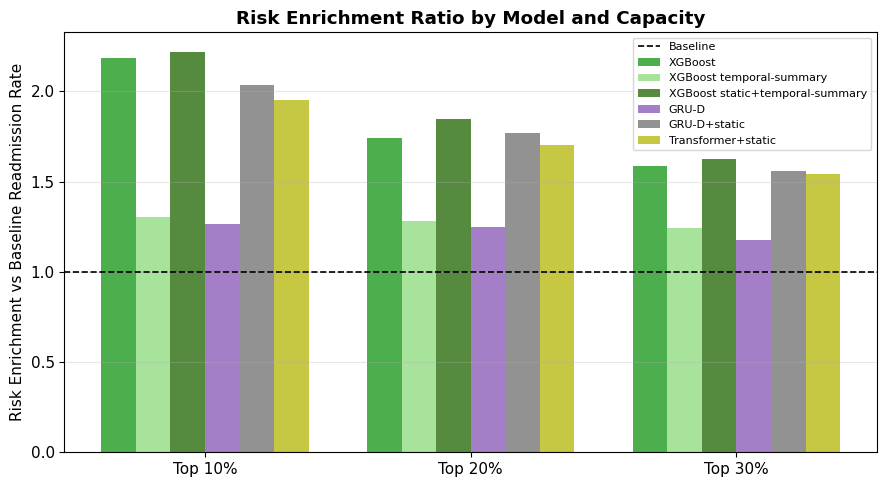

In [ ]:
# ── RQ5 Figure 3: Enrichment ratio ──
enrich_rows = []
for name, p_raw, _, _ in MODEL_PROBS:
    for k_pct in [0.10, 0.20, 0.30]:
        thresh  = np.percentile(p_raw, 100*(1-k_pct))
        top_idx = np.where(p_raw >= thresh)[0]
        prec    = float(y_test[top_idx].sum() / len(top_idx))
        enrich  = round(prec / y_test.mean(), 3)
        enrich_rows.append({'Model': name, 'K': f'Top {int(k_pct*100)}%', 'Enrichment': enrich})

df_enrich = pd.DataFrame(enrich_rows)
save_table(df_enrich, 'rq5_enrichment_ratio')

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3); width = 0.13
for i, name in enumerate(RQ5_MODELS):
    d = df_enrich[df_enrich.Model == name]
    ax.bar(x + i*width, d.Enrichment.values, width,
           label=name, color=COLORS[name], alpha=0.85)
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.2, label='Baseline')
ax.set_xticks(x + width*2.5)
ax.set_xticklabels(['Top 10%', 'Top 20%', 'Top 30%'])
ax.set_ylabel('Risk Enrichment vs Baseline Readmission Rate')
ax.set_title('Risk Enrichment Ratio by Model and Capacity', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
save_fig('rq5_fig3_enrichment_ratio')
plt.show()

---
# RQ6 — Hypothetical Implementation Impact

Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq6_fig1_hypothetical_avoidable_readmissions.pdf


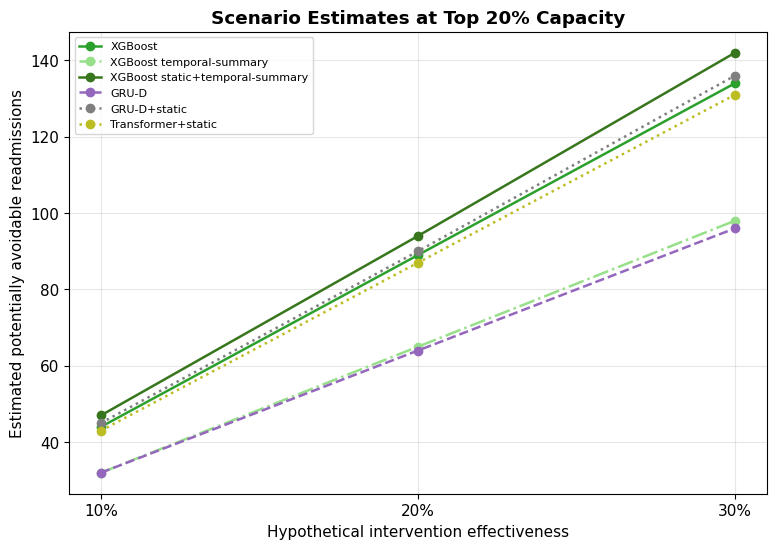

In [ ]:
# ── RQ6 Figure 1: Avoided readmissions — 6 representative models ──

model_lookup_raw = {name: p_raw for name, p_raw, _, _ in MODEL_PROBS}
capacities    = [0.10, 0.20, 0.30]
effectiveness = [0.10, 0.20, 0.30]
RQ6_MODELS = [
    'XGBoost',
    'XGBoost temporal-summary',
    'XGBoost static+temporal-summary',
    'GRU-D',
    'GRU-D+static',
    'Transformer+static'
]

plt.figure(figsize=(9, 6))
for name in RQ6_MODELS:
    p_raw = model_lookup_raw[name]
    thresh = np.percentile(p_raw, 80)
    readm  = int(y_test[p_raw >= thresh].sum())
    avoided = [int(readm * e) for e in effectiveness]
    plt.plot([f'{int(e*100)}%' for e in effectiveness], avoided,
             'o-', label=name, color=COLORS[name], linestyle=LS[name], linewidth=1.8)
plt.xlabel('Hypothetical intervention effectiveness')
plt.ylabel('Estimated potentially avoidable readmissions')
plt.title('Scenario Estimates at Top 20% Capacity', fontweight='bold')
plt.legend(fontsize=8); plt.grid(alpha=0.3)
save_fig('rq6_fig1_hypothetical_avoidable_readmissions')
plt.show()

Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq6_fig2_model_comparison_capacity.pdf


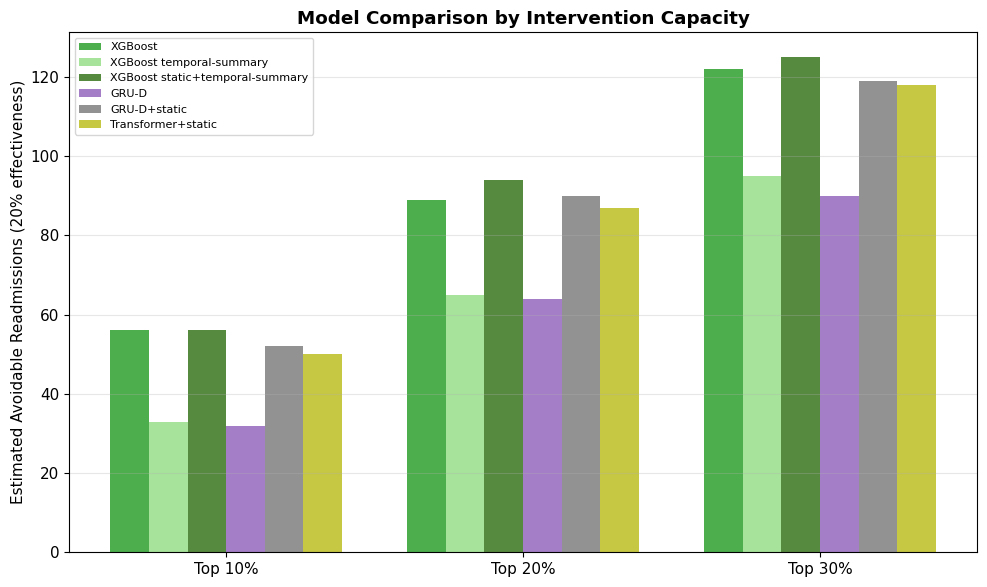

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(capacities)); width = 0.13
for i, name in enumerate(RQ6_MODELS):
    p_raw = model_lookup_raw[name]
    avoided = []
    for cap in capacities:
        thresh = np.percentile(p_raw, 100*(1-cap))
        readm  = int(y_test[p_raw >= thresh].sum())
        avoided.append(int(readm * 0.20))
    ax.bar(x + i*width, avoided, width, label=name, color=COLORS[name], alpha=0.85)
ax.set_xticks(x + width*2.5)
ax.set_xticklabels([f'Top {int(c*100)}%' for c in capacities])
ax.set_ylabel('Estimated Avoidable Readmissions (20% effectiveness)')
ax.set_title('Model Comparison by Intervention Capacity', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
save_fig('rq6_fig2_model_comparison_capacity')
plt.show()

---
# RQ7 — Transparency of the Deployable Model

SHAP explanation model: XGBoost static+temporal-summary
SHAP values shape: (7416, 72)
                   Feature  Mean_Abs_SHAP                  Feature_Group
           prev_admissions       0.373651    Static clinical/utilization
           los_days_capped       0.254822    Static clinical/utilization
                       age       0.071648    Static clinical/utilization
             num_diagnoses       0.064257    Static clinical/utilization
                 spo2_last       0.033722 Temporal summary / missingness
            heart_rate_std       0.031218 Temporal summary / missingness
     nibp_map_missing_frac       0.029052 Temporal summary / missingness
         temperature_f_min       0.024045 Temporal summary / missingness
                 spo2_mean       0.023856 Temporal summary / missingness
             resp_rate_max       0.022306 Temporal summary / missingness
            resp_rate_mean       0.020720 Temporal summary / missingness
           heart_rate_last       0.020

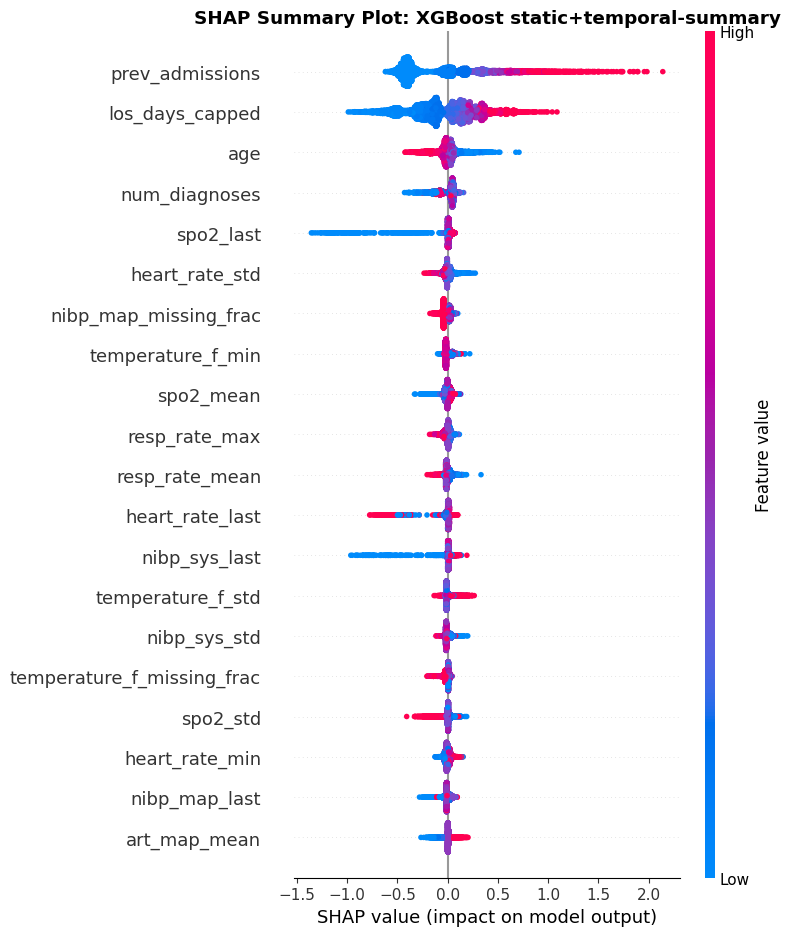

Saved figure: /content/drive/MyDrive/Thesis/thesis_v3/figures/rq7_fig2_shap_bar_deployable_model.pdf


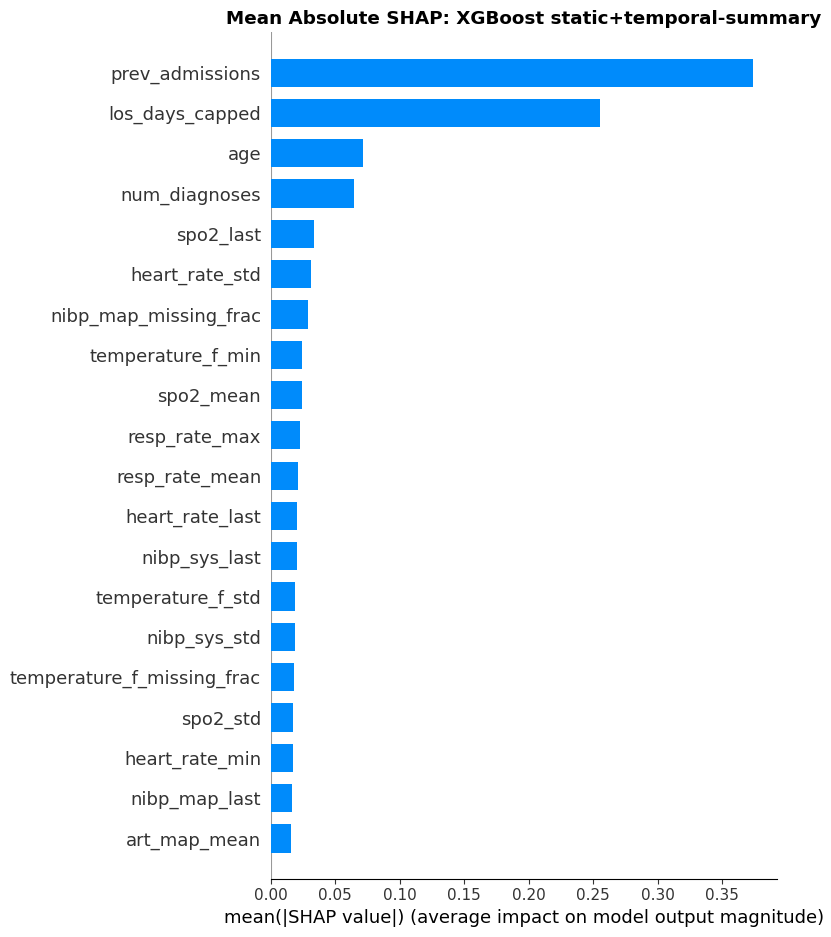


SHAP feature-group contribution:
                 Feature_Group  Mean_Abs_SHAP  Relative_Contribution
   Static clinical/utilization       0.775292                 0.5401
Temporal summary / missingness       0.660059                 0.4599
Saved table: /content/drive/MyDrive/Thesis/thesis_v3/tables/rq7_shap_feature_group_contribution.csv


In [ ]:
# !pip install shap -q
import shap

# SHAP is reported for the best-performing XGBoost-family model because tree SHAP
# is stable, fast, and appropriate for the deployable classical ML model.
xgb_candidates = [m for m in df_ranked.Model if m.startswith('XGBoost')]
SHAP_MODEL_NAME = xgb_candidates[0] if len(xgb_candidates) > 0 else 'XGBoost'
print('SHAP explanation model:', SHAP_MODEL_NAME)

if SHAP_MODEL_NAME == 'XGBoost':
    shap_model = xgb
    X_shap = np.load(ARRAY_STR + '/X_static_test.npy')
    shap_feature_names = STATIC_FEATURES
elif SHAP_MODEL_NAME == 'XGBoost temporal-summary':
    shap_model = xgb_ts
    X_shap = np.load(ARRAY_STR + '/X_temporal_summary_test.npy')
    shap_feature_names = TS_FEATURES
else:
    shap_model = xgb_st_ts
    X_shap = np.load(ARRAY_STR + '/X_static_temporal_summary_test.npy')
    shap_feature_names = ST_TS_FEATURES

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)
print('SHAP values shape:', shap_values.shape)

mean_shap = np.abs(shap_values).mean(axis=0)
df_rq7 = pd.DataFrame({'Feature': shap_feature_names, 'Mean_Abs_SHAP': mean_shap})
df_rq7 = df_rq7.sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)
df_rq7['Feature_Group'] = np.where(df_rq7['Feature'].isin(STATIC_FEATURES), 'Static clinical/utilization', 'Temporal summary / missingness')
print(df_rq7.head(30).to_string(index=False))
save_table(df_rq7, 'rq7_shap_importance_deployable_xgboost_family_model')

# Full beeswarm can be unreadable for many temporal-summary features, so show top 30.
top_features = df_rq7.head(min(30, len(df_rq7)))['Feature'].tolist()
top_idx = [shap_feature_names.index(f) for f in top_features]

plt.figure(figsize=(9,7))
shap.summary_plot(shap_values[:, top_idx], X_shap[:, top_idx], feature_names=top_features, show=False)
plt.title(f'SHAP Summary Plot: {SHAP_MODEL_NAME}', fontweight='bold')
plt.tight_layout(); save_fig('rq7_fig1_shap_beeswarm_deployable_model'); plt.show()

plt.figure(figsize=(8,7))
shap.summary_plot(shap_values[:, top_idx], X_shap[:, top_idx], feature_names=top_features, plot_type='bar', show=False)
plt.title(f'Mean Absolute SHAP: {SHAP_MODEL_NAME}', fontweight='bold')
plt.tight_layout(); save_fig('rq7_fig2_shap_bar_deployable_model'); plt.show()

# Feature-group contribution summary: static vs temporal-summary, if applicable.
df_rq7_group = df_rq7.groupby('Feature_Group', as_index=False)['Mean_Abs_SHAP'].sum()
df_rq7_group['Relative_Contribution'] = (df_rq7_group['Mean_Abs_SHAP'] / df_rq7_group['Mean_Abs_SHAP'].sum()).round(4)
print('\nSHAP feature-group contribution:')
print(df_rq7_group.to_string(index=False))
save_table(df_rq7_group, 'rq7_shap_feature_group_contribution')


## Final Check — File Inventory

In [ ]:
print('=== MODELS ==='); print(sorted(os.listdir(MODEL_STR)))
print('\n=== ARRAYS ==='); print(sorted(os.listdir(ARRAY_STR)))
print('\n=== TABLES ==='); print(sorted(os.listdir(TABLE_STR)))
print('\n=== FIGURES ==='); print(sorted(os.listdir(FIG_STR)))

=== MODELS ===
['gru.pth', 'gru_best.pth', 'gru_static.pth', 'gru_static_best.pth', 'grud.pth', 'grud_best.pth', 'grud_static.pth', 'grud_static_best.pth', 'lr_model.pkl', 'lr_static_temporal_summary_model.pkl', 'lr_temporal_summary_model.pkl', 'rf_model.pkl', 'rf_static_temporal_summary_model.pkl', 'rf_temporal_summary_model.pkl', 'scaler_static.pkl', 'temporal_summary_imputer.pkl', 'temporal_summary_scaler.pkl', 'transformer.pth', 'transformer_best.pth', 'transformer_static.pth', 'transformer_static_best.pth', 'xgb_model.pkl', 'xgb_static_temporal_summary_model.pkl', 'xgb_temporal_summary_model.pkl']

=== ARRAYS ===
['X_static_temporal_summary_test.npy', 'X_static_test.npy', 'X_temporal_summary_test.npy', 'p_gru.npy', 'p_gru_st.npy', 'p_grud.npy', 'p_grud_st.npy', 'p_lr.npy', 'p_lr_st_ts.npy', 'p_lr_ts.npy', 'p_rf.npy', 'p_rf_st_ts.npy', 'p_rf_ts.npy', 'p_trans.npy', 'p_trans_st.npy', 'p_xgb.npy', 'p_xgb_st_ts.npy', 'p_xgb_ts.npy', 'split_all.npy', 'y_all.npy', 'y_test.npy', 'years_a

In [ ]:
import joblib
import torch
import numpy as np

# Test baseline models load
lr_test  = joblib.load(MODEL_STR + '/lr_model.pkl')
rf_test  = joblib.load(MODEL_STR + '/rf_model.pkl')
xgb_test = joblib.load(MODEL_STR + '/xgb_model.pkl')
print('✅ Static LR, RF, XGBoost load OK')

# Test added temporal-summary models load
for f in [
    'lr_temporal_summary_model.pkl','rf_temporal_summary_model.pkl','xgb_temporal_summary_model.pkl',
    'lr_static_temporal_summary_model.pkl','rf_static_temporal_summary_model.pkl','xgb_static_temporal_summary_model.pkl'
]:
    _ = joblib.load(MODEL_STR + '/' + f)
print('✅ Temporal-summary and static+temporal-summary ML models load OK')

# Test DL models load
gru_test = GRUModel()
gru_test.load_state_dict(torch.load(MODEL_STR + '/gru.pth', map_location='cpu'))
print('✅ GRU load OK')

grud_test = GRUDModel()
grud_test.load_state_dict(torch.load(MODEL_STR + '/grud.pth', map_location='cpu'))
print('✅ GRU-D load OK')

trans_test = TransformerModel()
trans_test.load_state_dict(torch.load(MODEL_STR + '/transformer.pth', map_location='cpu'))
print('✅ Transformer load OK')

gru_st_test = GRUStaticModel()
gru_st_test.load_state_dict(torch.load(MODEL_STR + '/gru_static.pth', map_location='cpu'))
print('✅ GRU+static load OK')

grud_st_test = GRUDStaticModel()
grud_st_test.load_state_dict(torch.load(MODEL_STR + '/grud_static.pth', map_location='cpu'))
print('✅ GRU-D+static load OK')

trans_st_test = TransformerStaticModel()
trans_st_test.load_state_dict(torch.load(MODEL_STR + '/transformer_static.pth', map_location='cpu'))
print('✅ Transformer+static load OK')

# Test arrays
y_test_check = np.load(ARRAY_STR + '/y_test.npy')
print('✅ y_test shape:', y_test_check.shape)
for f in ['X_static_test.npy','X_temporal_summary_test.npy','X_static_temporal_summary_test.npy','years_test.npy']:
    arr = np.load(ARRAY_STR + '/' + f, allow_pickle=True)
    print(f'✅ {f} shape:', arr.shape)

# Journal safety outputs that must exist after a full run.
required_tables = [
    'journal_split_year_audit.csv',
    'rq3_raw_vs_calibrated_metrics.csv',
    'rq3_calibration_raw_vs_platt.csv',
    'rq4_yearwise_temporal_robustness.csv',
    'rq4_subgroup_robustness_best_model.csv',
    'rq4_missingness_stress_test_summary.csv',
    'rq5_precision_recall_at_10_20_30_percent.csv',
    'rq6_hypothetical_implementation_impact.csv',
    'rq7_shap_importance_deployable_xgboost_family_model.csv',
    'journal_model_ranking_by_auroc_auprc.csv'
]
missing_tables = [f for f in required_tables if not os.path.exists(TABLE_STR + '/' + f)]
if missing_tables:
    print('⚠️ Missing journal-safety tables. Run all cells from the top. Missing:', missing_tables)
else:
    print('✅ All journal-safety tables are present.')

print('\n🎉 NOTEBOOK CHECK COMPLETE.')
print('Allowed temporal claim:', TEMPORAL_VALIDATION_CLAIM)
print('Best model by AUROC/AUPRC:', BEST_MODEL_NAME)
print('Use cautious wording: scenario estimates are hypothetical, not causal evidence of prevented readmissions.')


✅ Static LR, RF, XGBoost load OK
✅ Temporal-summary and static+temporal-summary ML models load OK
✅ GRU load OK
✅ GRU-D load OK
✅ Transformer load OK
✅ GRU+static load OK
✅ GRU-D+static load OK
✅ Transformer+static load OK
✅ y_test shape: (7416,)
✅ X_static_test.npy shape: (7416, 6)
✅ X_temporal_summary_test.npy shape: (7416, 66)
✅ X_static_temporal_summary_test.npy shape: (7416, 72)
✅ years_test.npy shape: (7416,)
✅ All journal-safety tables are present.

🎉 NOTEBOOK CHECK COMPLETE.
Allowed temporal claim: strict chronological validation
Best model by AUROC/AUPRC: XGBoost static+temporal-summary
Use cautious wording: scenario estimates are hypothetical, not causal evidence of prevented readmissions.


In [ ]:
import os
figs = sorted(os.listdir(FIG_STR))
print('=== FIGURES ===')
for f in figs:
    print(f)
print('Total figures:', len(figs))

=== FIGURES ===
rq1_fig1_roc_curves.pdf
rq1_fig2_pr_curves.pdf
rq1_fig3_ablation_auroc.pdf
rq1_fig4_xgboost_variants.pdf
rq2_fig1_model_complexity_comparison.pdf
rq3_calibration_before_after_xgboost.pdf
rq3_calibration_before_after_xgboost_staticplustemporal-summary.pdf
rq3_fig1_reliability_diagrams.pdf
rq3_fig2_dca.pdf
rq3_fig3_obs_vs_pred.pdf
rq4_fig1_yearwise_auroc.pdf
rq4_fig2_subgroup_best_model.pdf
rq4b_fig1_auroc_vs_missingness_repeated.pdf
rq5_fig1_capture_curve.pdf
rq5_fig2_tier_distribution.pdf
rq5_fig3_enrichment_ratio.pdf
rq6_fig1_hypothetical_avoidable_readmissions.pdf
rq6_fig2_model_comparison_capacity.pdf
rq7_fig1_shap_beeswarm_deployable_model.pdf
rq7_fig2_shap_bar_deployable_model.pdf
Total figures: 20
